# Загрузка данных

In [1]:
import numpy as np
import pandas as pd

In [2]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('scintillation-detector')

print("Path to competition files:", path)

Path to competition files: /home/itj/.cache/kagglehub/competitions/scintillation-detector


In [3]:
# Data loading

dataset = pd.read_csv(path + '/' + 'Run200_Wave_0_1.txt', sep=' ', header=None, skipinitialspace=True)

In [4]:
dataset.head()

,0,1,2,3,4,5,6,7,8,9,...,495,496,497,498,499,500,501,502,503,504
0,2890276,357,113,500,14820,14823,14824,14822,14818,14820,...,14822,14815,14815,14817,14819,14820,14822,14820,14819,NaN
1,4928764,740,359,500,14820,14822,14820,14826,14824,14822,...,14817,14824,14822,14824,14819,14820,14819,14822,14820,NaN
2,9630204,162,499,500,14820,14820,14822,14825,14820,14824,...,14821,14820,14820,14818,14821,14823,14820,14820,14821,NaN
3,15798632,841,123,500,14828,14822,14818,14824,14824,14822,...,14826,14822,14821,14820,14828,14820,14822,14823,14822,NaN
4,20637296,412,348,500,14823,14815,14823,14821,14827,14820,...,14820,14823,14828,14824,14820,14824,14824,14822,14825,NaN


In [5]:
dataset = dataset.drop([0, 1, 2, 3, 504], axis=1)
dataset.columns = list(range(500))
dataset.head()

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,14820,14823,14824,14822,14818,14820,14824,14822,14820,14820,...,14828,14822,14815,14815,14817,14819,14820,14822,14820,14819
1,14820,14822,14820,14826,14824,14822,14820,14822,14823,14821,...,14828,14817,14824,14822,14824,14819,14820,14819,14822,14820
2,14820,14820,14822,14825,14820,14824,14824,14819,14823,14824,...,14820,14821,14820,14820,14818,14821,14823,14820,14820,14821
3,14828,14822,14818,14824,14824,14822,14820,14822,14824,14820,...,14824,14826,14822,14821,14820,14828,14820,14822,14823,14822
4,14823,14815,14823,14821,14827,14820,14823,14824,14816,14821,...,14820,14820,14823,14828,14824,14820,14824,14824,14822,14825


In [6]:
dataset.shape

(23479, 500)

Text(0, 0.5, 'bit ADC')

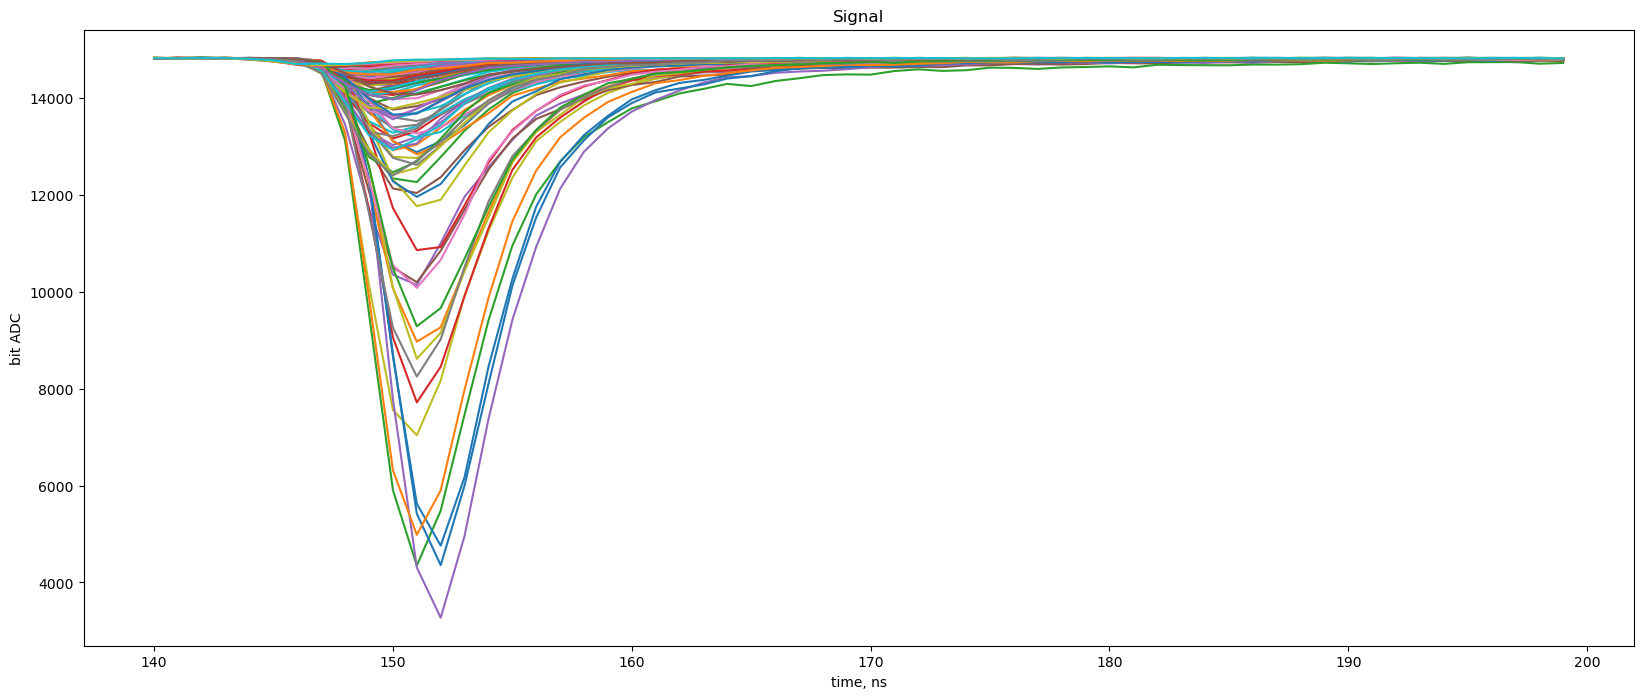

In [7]:
N=range(0,100)
ax = dataset.T[N][140:200].plot(title='Signal' ,legend=None,figsize=(20,8))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")

Text(0, 0.5, 'bit ADC')

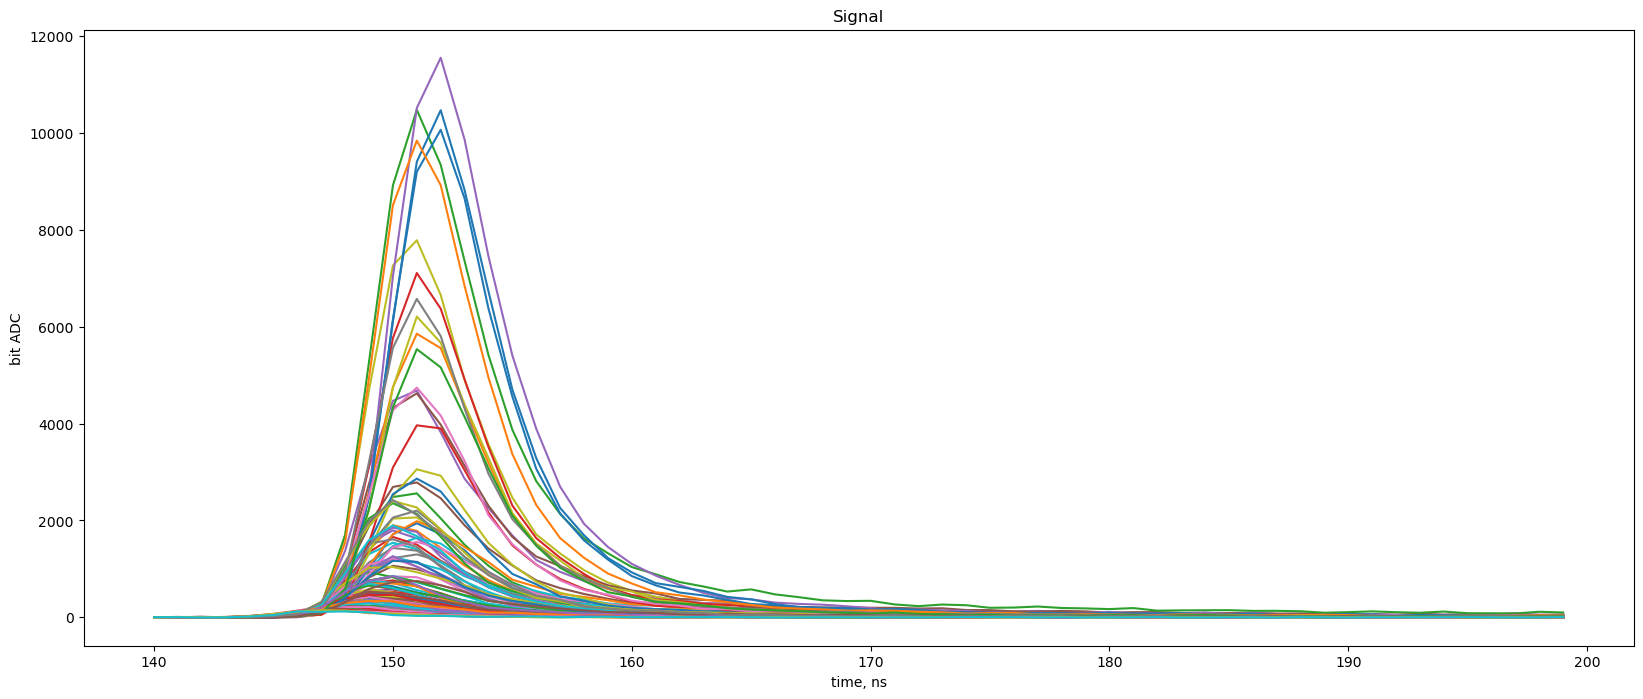

In [8]:
ax = (2**14-dataset.T[N]-1560)[140:200].plot(title='Signal' ,legend=None,figsize=(20,8))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")


Text(0, 0.5, 'bit ADC')

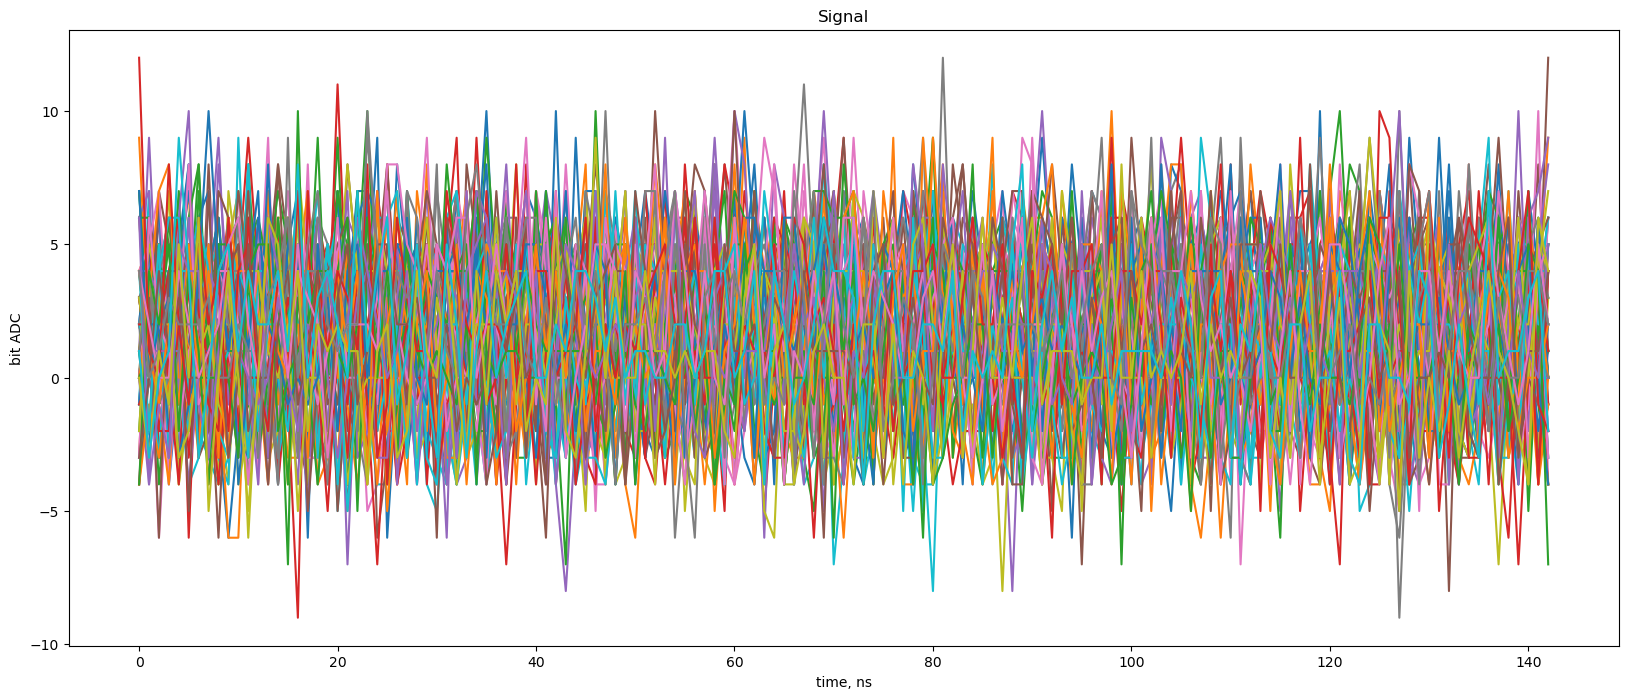

In [9]:
ax = (2**14-dataset.T[N]-1560)[:143].plot(title='Signal' ,legend=None,figsize=(20,8))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")


Text(0, 0.5, 'bit ADC')

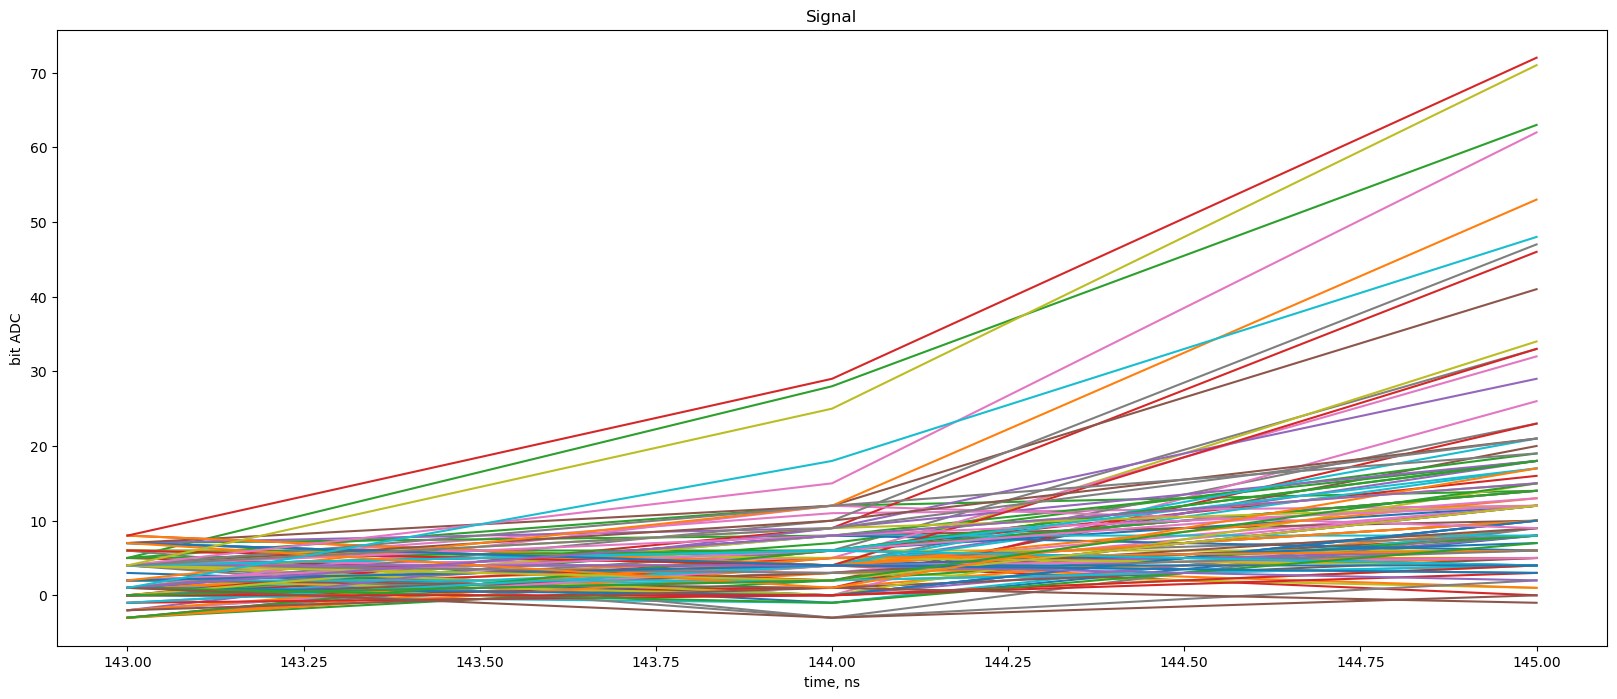

In [10]:
ax = (2**14-dataset.T[N]-1560)[143:146].plot(title='Signal' ,legend=None,figsize=(20,8))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")


Text(0, 0.5, 'bit ADC')

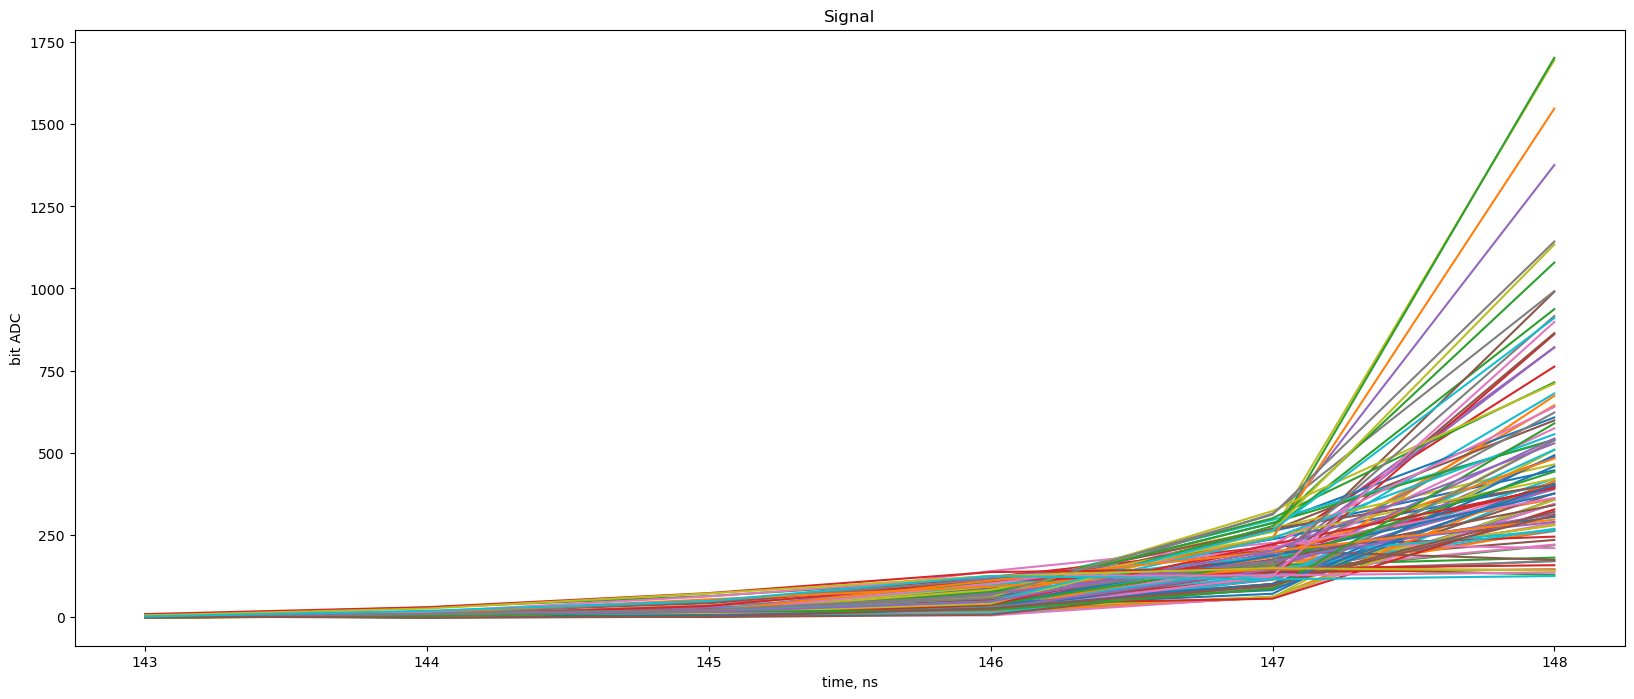

In [11]:
ax = (2**14-dataset.T[N]-1560)[143:149].plot(title='Signal' ,legend=None,figsize=(20,8))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")


Text(0, 0.5, 'bit ADC')

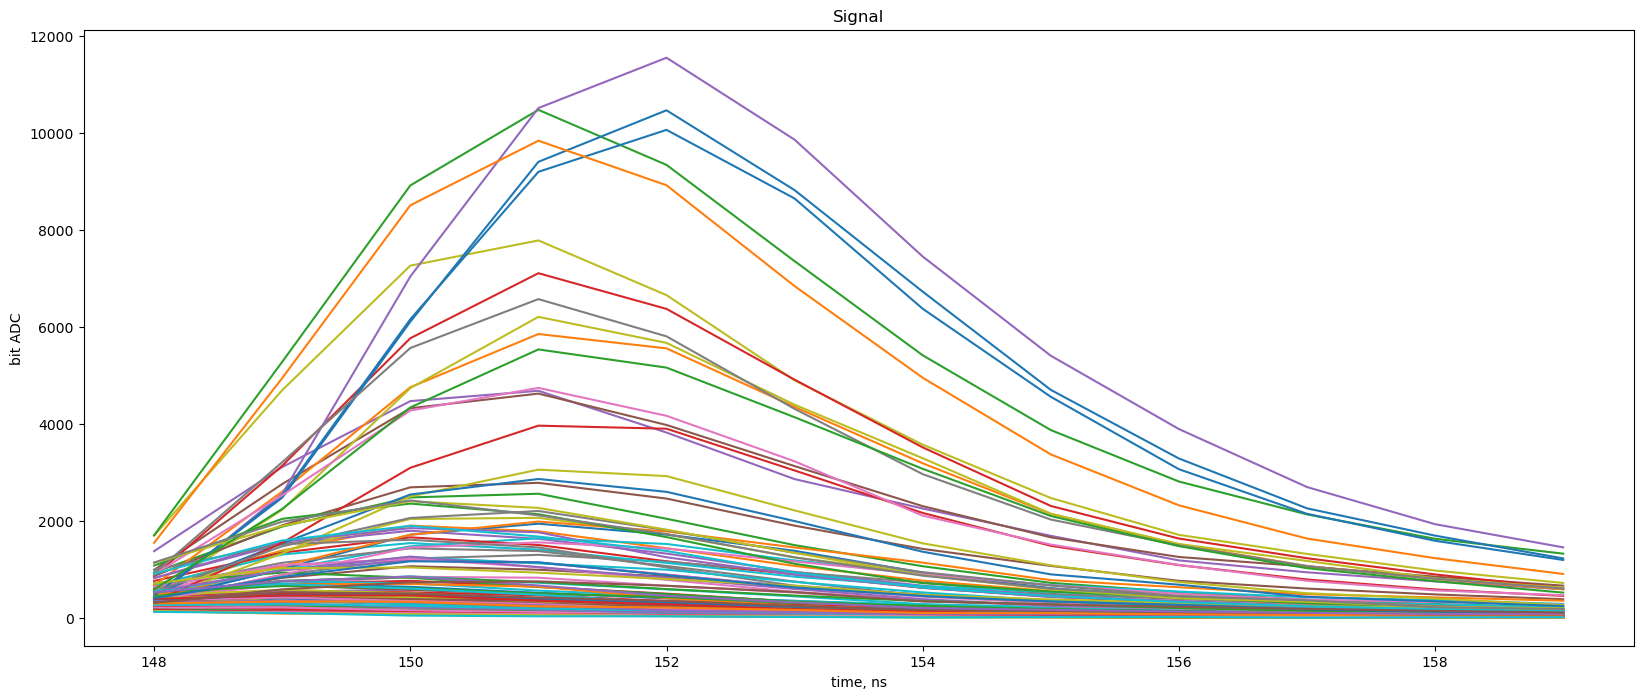

In [12]:
ax = (2**14-dataset.T[N]-1560)[148:160].plot(title='Signal' ,legend=None,figsize=(20,8))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")


Text(0, 0.5, 'bit ADC')

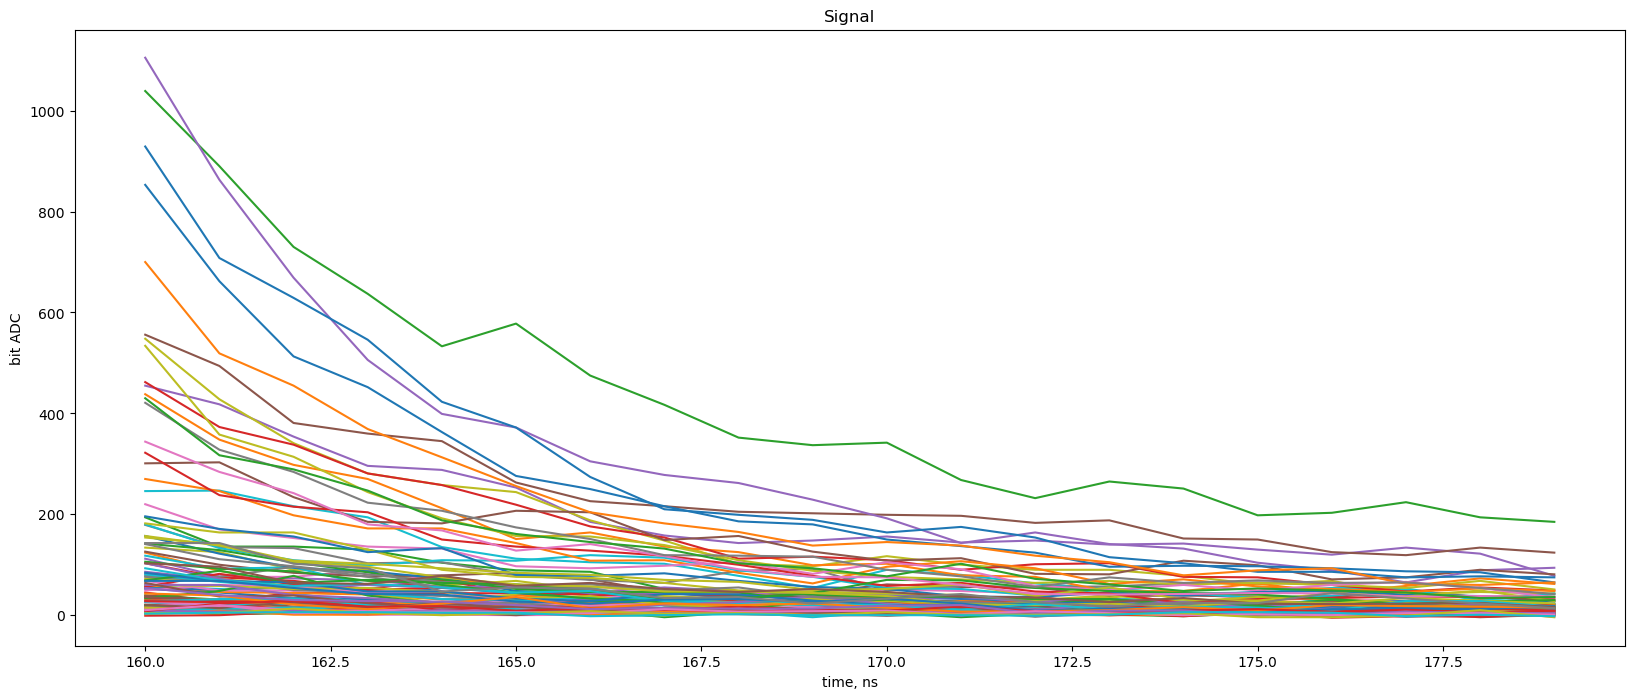

In [13]:
ax = (2**14-dataset.T[N]-1560)[160:180].plot(title='Signal' ,legend=None,figsize=(20,8))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")


Text(0, 0.5, 'bit ADC')

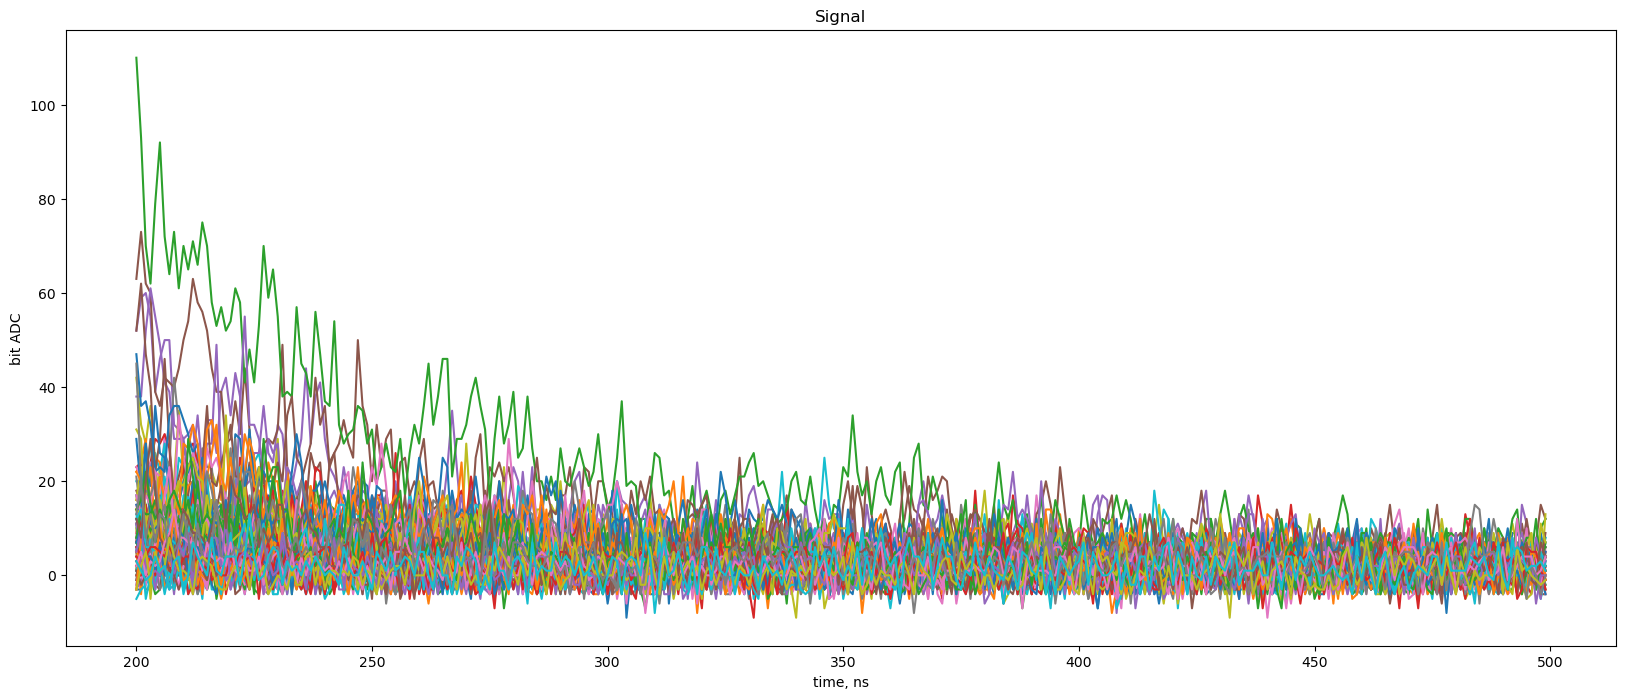

In [14]:
ax = (2**14-dataset.T[N]-1560)[200:500].plot(title='Signal' ,legend=None,figsize=(20,8))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")


Text(0, 0.5, 'bit ADC')

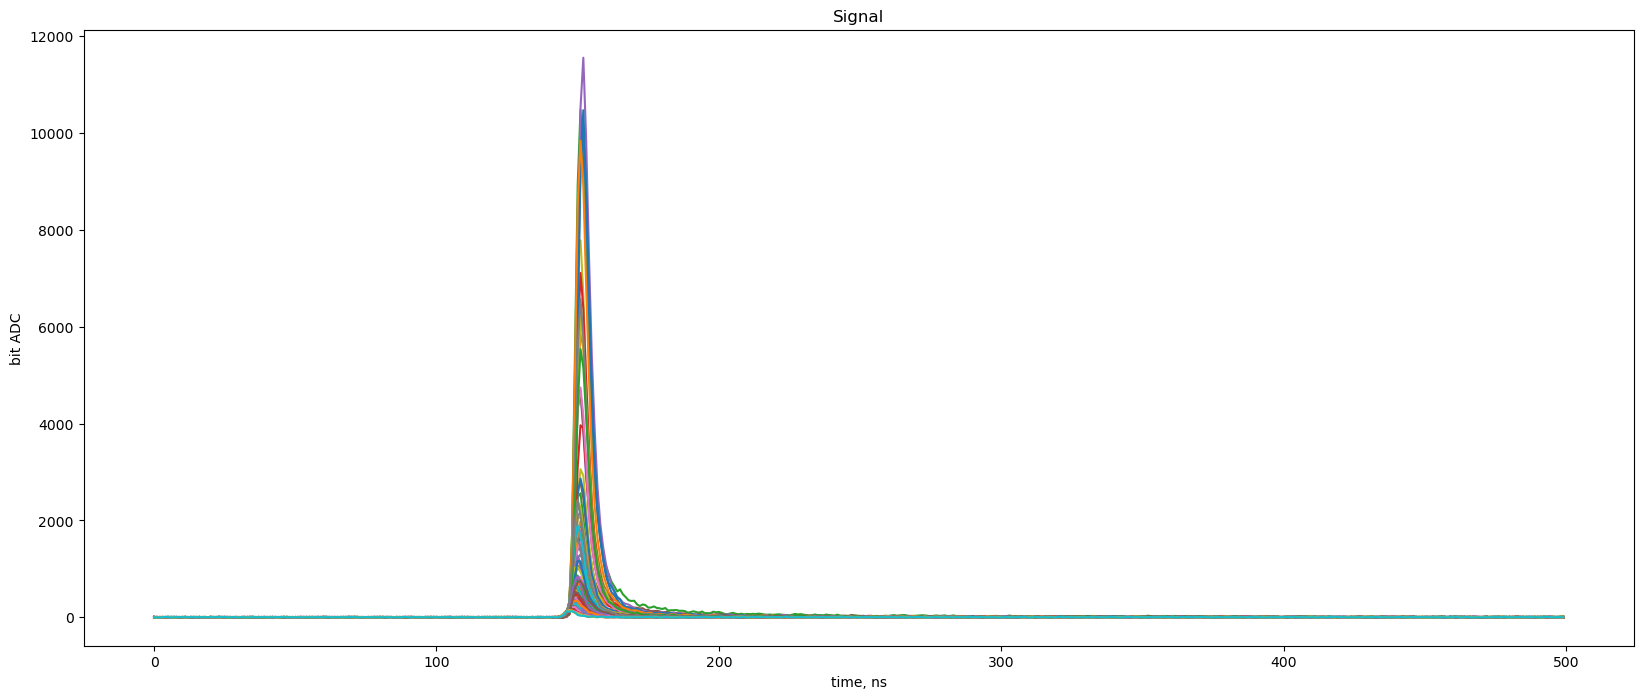

In [15]:
ax = (2**14-dataset.T[N]-1560).plot(title='Signal' ,legend=None,figsize=(20,8))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")


Text(0, 0.5, 'bit ADC')

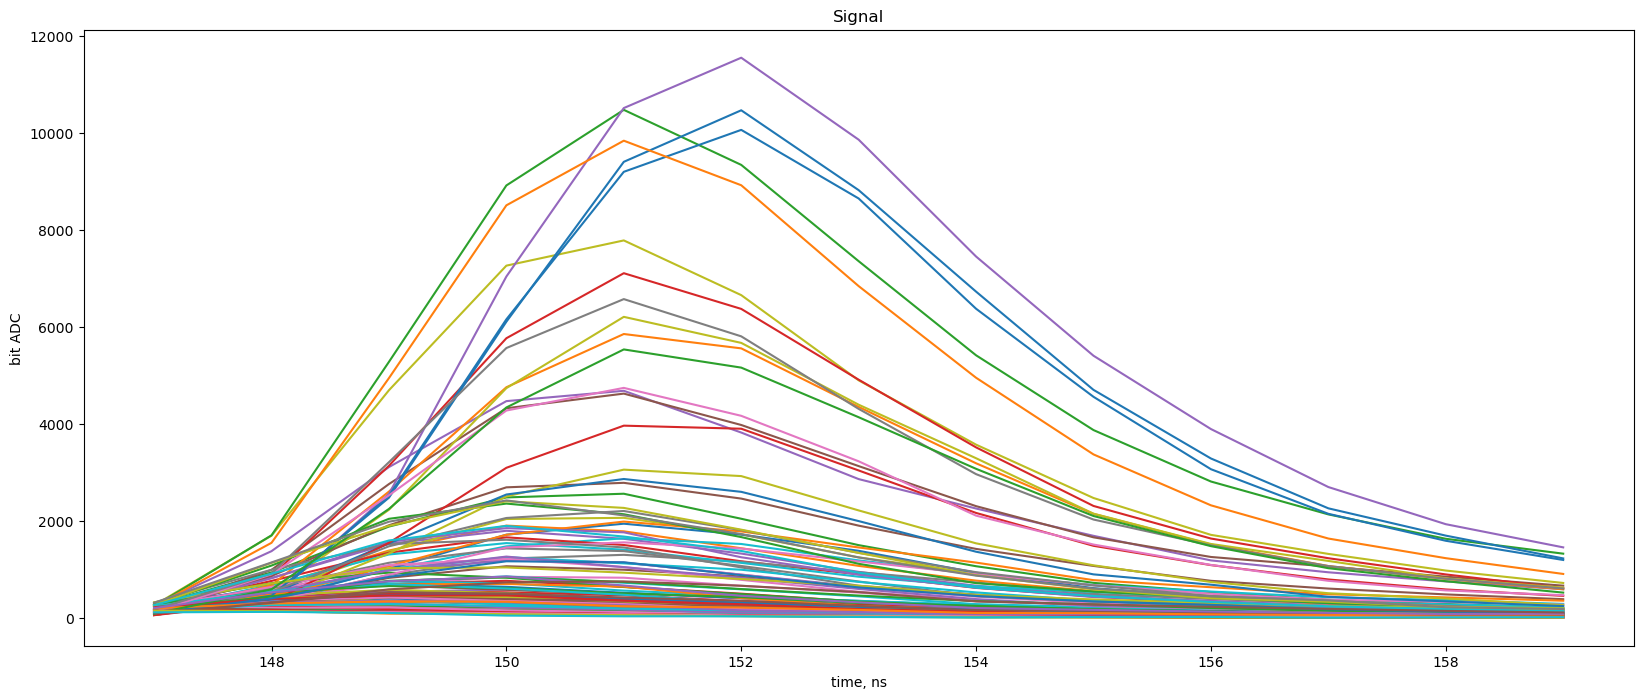

In [16]:
ax = (2**14-dataset.T[N]-1560)[147:160].plot(title='Signal' ,legend=None,figsize=(20,8))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")


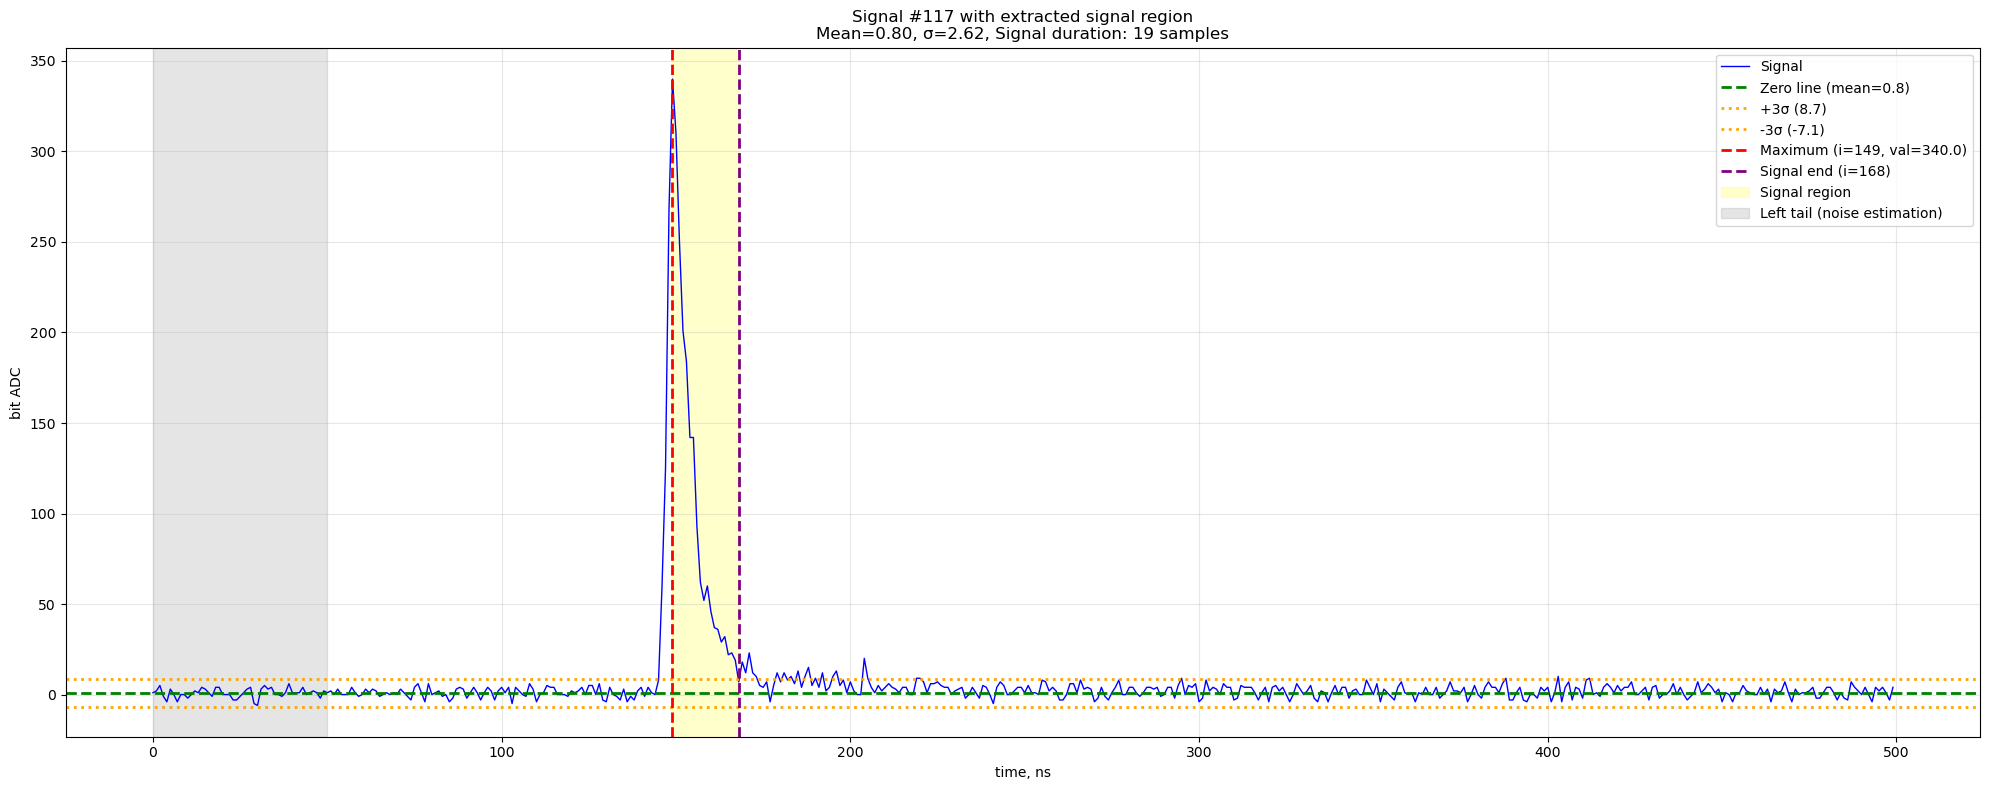

Сигнал #117:
  Нулевая линия (среднее левого хвоста): 0.80
  Стандартное отклонение шума: 2.62
  Индекс максимума: 149
  Значение максимума: 340.00
  Конец сигнала: 168
  Длительность сигнала: 19 отсчётов


In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Берём один сигнал для наглядной демонстрации
signal_idx = 117
signal = (2**14 - dataset.T[signal_idx] - 1560).values

# Параметры выделения сигнала
left_tail_length = 50  # первые 50 отсчётов - левый хвост (шум)
n_sigma = 3            # порог в стандартных отклонениях

# 1. Нулевая линия = среднее значение левого хвоста
zero_line = np.mean(signal[:left_tail_length])
# 2. Стандартное отклонение шума
noise_std = np.std(signal[:left_tail_length])

# 3. Находим индекс максимума
i_max = np.argmax(signal)

# 4. Ищем конец сигнала: идём от максимума вправо, 
#    ищем первый индекс где |signal - zero_line| <= n_sigma * noise_std
signal_end = i_max
for i in range(i_max, len(signal)):
    if abs(signal[i] - zero_line) <= n_sigma * noise_std:
        signal_end = i
        break

# 5. Визуализация
fig, ax = plt.subplots(figsize=(20, 8))

# Рисуем сигнал
ax.plot(signal, color='blue', linewidth=1, label='Signal')

# Нулевая линия (среднее левого хвоста)
ax.axhline(y=zero_line, color='green', linestyle='--', linewidth=2, 
           label=f'Zero line (mean={zero_line:.1f})')

# Границы ±3σ от нулевой линии
ax.axhline(y=zero_line + n_sigma * noise_std, color='orange', linestyle=':', 
           linewidth=2, label=f'+{n_sigma}σ ({zero_line + n_sigma*noise_std:.1f})')
ax.axhline(y=zero_line - n_sigma * noise_std, color='orange', linestyle=':', 
           linewidth=2, label=f'-{n_sigma}σ ({zero_line - n_sigma*noise_std:.1f})')

# Вертикальная линия максимума
ax.axvline(x=i_max, color='red', linestyle='--', linewidth=2, 
           label=f'Maximum (i={i_max}, val={signal[i_max]:.1f})')

# Вертикальная линия конца сигнала
ax.axvline(x=signal_end, color='purple', linestyle='--', linewidth=2, 
           label=f'Signal end (i={signal_end})')

# Заштриховываем область сигнала
ax.axvspan(i_max, signal_end, alpha=0.2, color='yellow', label='Signal region')

# Заштриховываем левый хвост (область шума для оценки параметров)
ax.axvspan(0, left_tail_length, alpha=0.2, color='gray', label='Left tail (noise estimation)')

ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")
ax.set_title(f'Signal #{signal_idx} with extracted signal region\n'
             f'Mean={zero_line:.2f}, σ={noise_std:.2f}, '
             f'Signal duration: {signal_end - i_max} samples')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Сигнал #{signal_idx}:")
print(f"  Нулевая линия (среднее левого хвоста): {zero_line:.2f}")
print(f"  Стандартное отклонение шума: {noise_std:.2f}")
print(f"  Индекс максимума: {i_max}")
print(f"  Значение максимума: {signal[i_max]:.2f}")
print(f"  Конец сигнала: {signal_end}")
print(f"  Длительность сигнала: {signal_end - i_max} отсчётов")

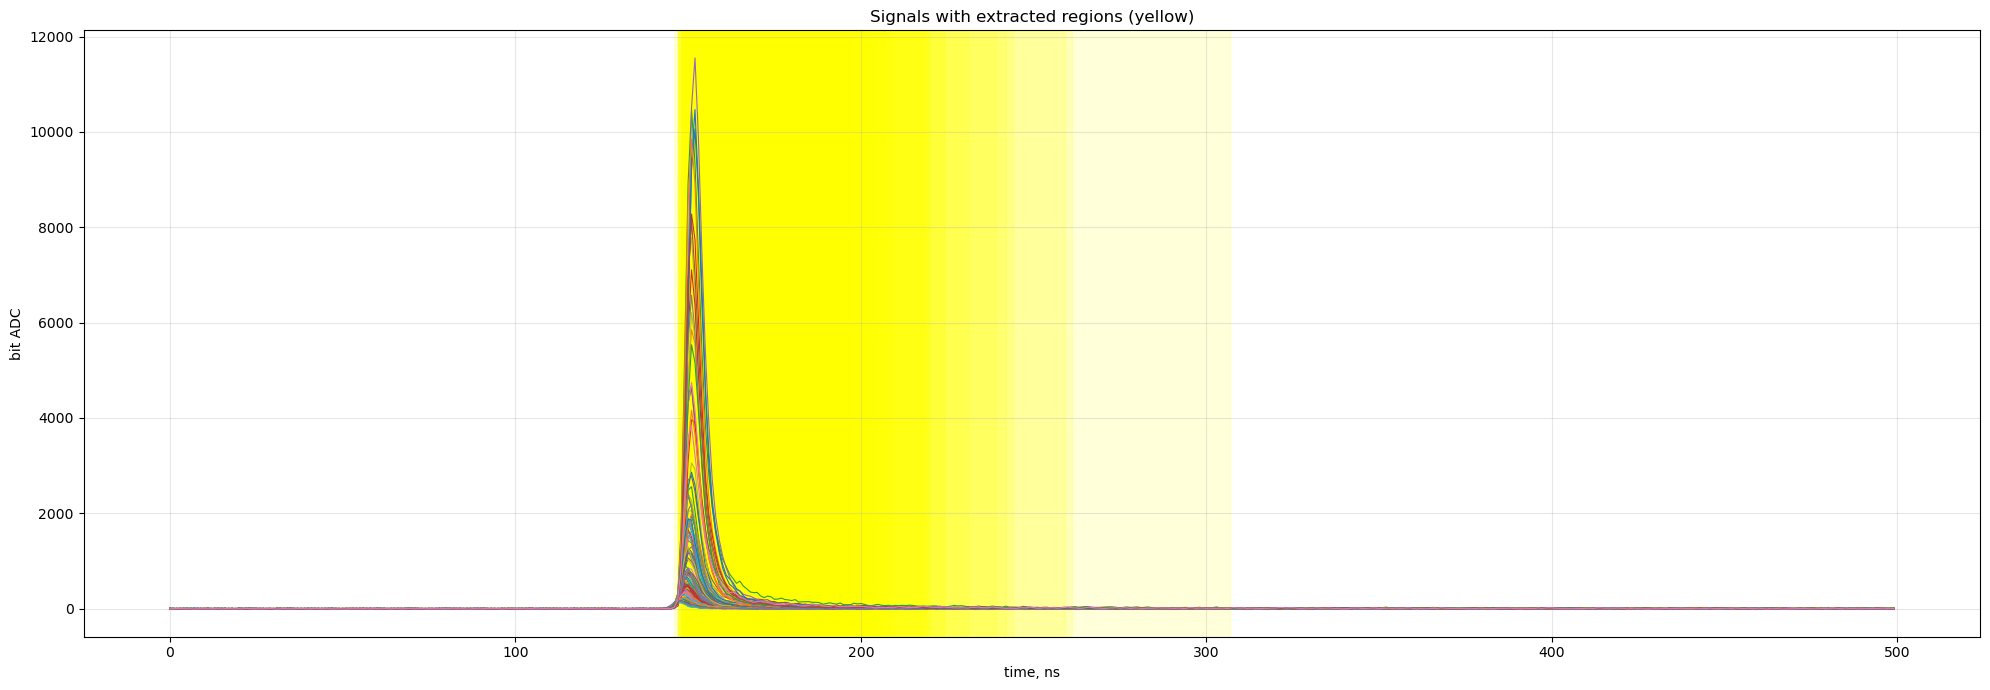

In [18]:
# Визуализация для нескольких сигналов с выделенными областями
N_demo = range(0, 117)
fig, ax = plt.subplots(figsize=(20, 7))

for idx in N_demo:
    signal = (2**14 - dataset.T[idx] - 1560).values
    
    zero_line = np.mean(signal[:left_tail_length])
    noise_std = np.std(signal[:left_tail_length])
    i_max = np.argmax(signal)
    
    signal_end = i_max
    for i in range(i_max, len(signal)):
        if abs(signal[i] - zero_line) <= n_sigma * noise_std:
            signal_end = i
            break
    
    ax.plot(signal, linewidth=0.8)
    ax.axvspan(i_max, signal_end, alpha=0.15, color='yellow')

ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")
ax.set_title('Signals with extracted regions (yellow)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Ячейка 1: Создание признаков (Feature Engineering)


In [19]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Функция для создания признаков из сигналов
def extract_features(dataset):
    """
    Извлекает признаки из сигналов сцинтилляционного детектора
    """
    n_signals = dataset.shape[0]
    
    # Инициализация массивов для признаков
    psd_values = np.zeros(n_signals)
    tau_values = np.zeros(n_signals)
    amplitude_values = np.zeros(n_signals)
    area_values = np.zeros(n_signals)
    baseline_mean = np.zeros(n_signals)
    baseline_std = np.zeros(n_signals)
    signal_duration = np.zeros(n_signals)
    
    # Параметры для PSD
    short_window = 10  # ширина окна short gate
    offset_from_max = 5  # отступ от максимума
    
    # Экспоненциальная функция для аппроксимации
    def exp_func(x, a, tau):
        return a * np.exp(-x / tau)
    
    for i in range(n_signals):
        signal = dataset.iloc[i].values
        
        # 1. Базовая линия (первые 50 отсчетов)
        baseline = signal[:50]
        baseline_mean[i] = np.mean(baseline)
        baseline_std[i] = np.std(baseline)
        
        # 2. Центрированный сигнал
        signal_centered = signal - baseline_mean[i]
        
        # 3. Амплитуда и позиция максимума
        max_idx = np.argmax(signal_centered)
        amplitude_values[i] = signal_centered[max_idx]
        
        # 4. Площадь под сигналом (long gate)
        area_values[i] = np.sum(signal_centered)
        
        # 5. PSD (Pulse Shape Discrimination)
        long_gate = np.sum(signal_centered)
        short_start = max_idx + offset_from_max
        short_end = short_start + short_window
        if short_end <= len(signal):
            short_gate = np.sum(signal_centered[short_start:short_end])
            psd_values[i] = (long_gate - short_gate) / long_gate if long_gate != 0 else 0
        else:
            psd_values[i] = 0
        
        # 6. Время высвечивания (Tau) - аппроксимация хвоста экспонентой
        # Берем хвост после максимума
        tail_start = max_idx + 10
        tail_end = min(max_idx + 100, len(signal))
        if tail_end > tail_start:
            x_tail = np.arange(tail_end - tail_start)
            y_tail = signal_centered[tail_start:tail_end]
            
            # Фильтруем нулевые и отрицательные значения
            valid_mask = y_tail > 0
            if np.sum(valid_mask) > 10:
                x_valid = x_tail[valid_mask]
                y_valid = y_tail[valid_mask]
                
                try:
                    # Начальные параметры
                    p0 = [y_valid[0], 20]
                    popt, _ = curve_fit(exp_func, x_valid, y_valid, p0=p0, maxfev=1000)
                    tau_values[i] = popt[1]
                except:
                    tau_values[i] = np.nan
            else:
                tau_values[i] = np.nan
        else:
            tau_values[i] = np.nan
        
        # 7. Длительность сигнала (до достижения 3σ от базовой линии)
        threshold = baseline_mean[i] + 3 * baseline_std[i]
        signal_end_idx = max_idx
        for j in range(max_idx, len(signal)):
            if signal[j] < threshold:
                signal_end_idx = j
                break
        signal_duration[i] = signal_end_idx - max_idx
    
    # Создаем DataFrame с признаками
    features = pd.DataFrame({
        'PSD': psd_values,
        'Tau': tau_values,
        'Amplitude': amplitude_values,
        'Area': area_values,
        'Baseline_Mean': baseline_mean,
        'Baseline_Std': baseline_std,
        'Signal_Duration': signal_duration
    })
    
    # Обработка NaN значений
    features = features.fillna(features.median())
    
    return features

# Извлекаем признаки
print("Извлечение признаков...")
features = extract_features(dataset)
print(f"Размерность признаков: {features.shape}")
print("\nСтатистика признаков:")
print(features.describe())

Извлечение признаков...
Размерность признаков: (23479, 7)

Статистика признаков:
                PSD           Tau     Amplitude           Area  Baseline_Mean  \
count  23479.000000  2.347900e+04  23479.000000   23479.000000   23479.000000   
mean       0.959922  1.256658e+08      7.744852  -13141.391754   14822.966507   
std        0.180534  2.549031e+08      1.260057   16097.184561       0.856405   
min       -0.115351 -1.755271e+09      3.860000 -113071.000000   14818.920000   
25%        0.997926  2.892037e+02      6.860000  -17291.000000   14822.380000   
50%        0.999722  4.765470e+03      7.680000   -6257.000000   14822.960000   
75%        1.000334  1.767169e+08      8.540000   -2447.000000   14823.540000   
max        1.060795  3.664022e+09     15.600000    -213.000000   14826.480000   

       Baseline_Std  Signal_Duration  
count  23479.000000     23479.000000  
mean       2.680664         0.398399  
std        0.264567         0.490535  
min        1.673440         0.000

# Ячейка 2: Визуализация признаков и гистограмм


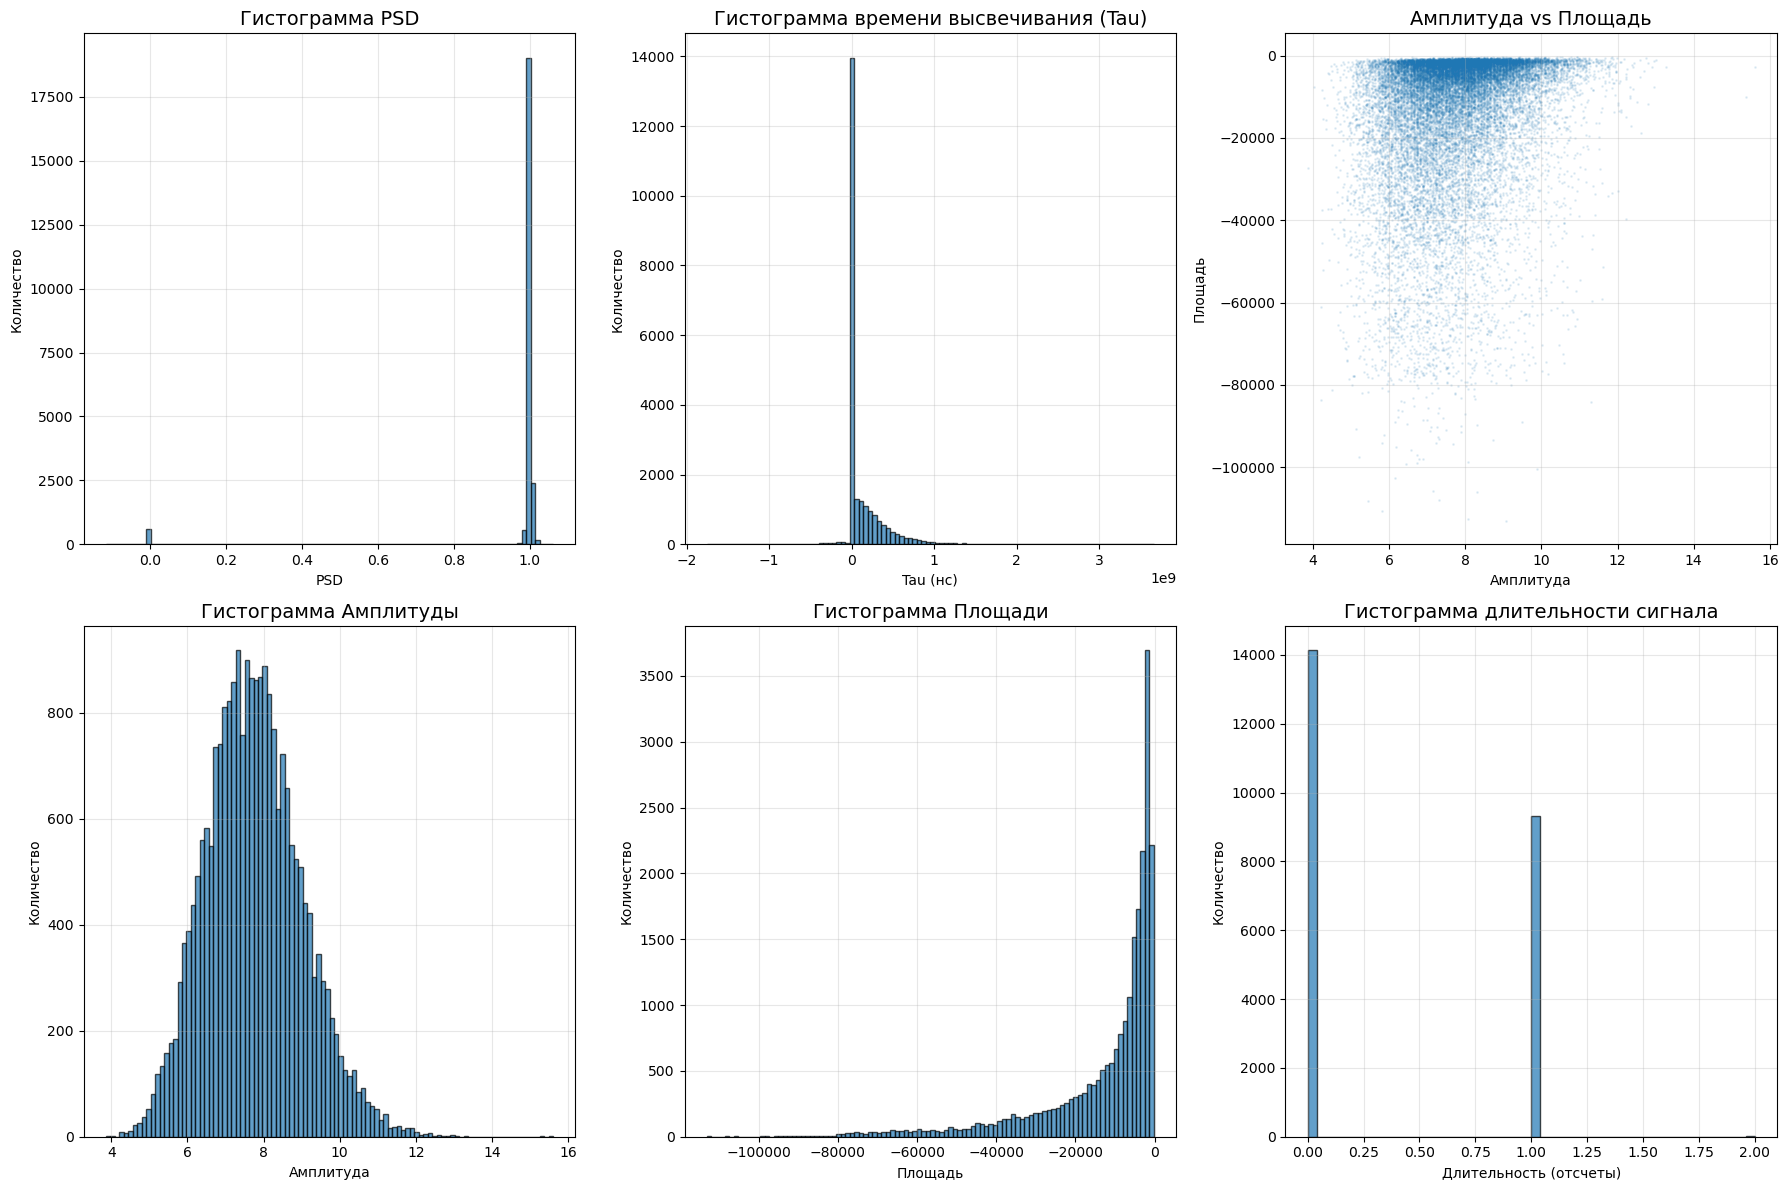

Признаки успешно извлечены и визуализированы


In [20]:
# Визуализация распределений признаков
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Гистограмма PSD
axes[0, 0].hist(features['PSD'].dropna(), bins=100, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Гистограмма PSD', fontsize=14)
axes[0, 0].set_xlabel('PSD')
axes[0, 0].set_ylabel('Количество')
axes[0, 0].grid(True, alpha=0.3)

# Гистограмма Tau
axes[0, 1].hist(features['Tau'].dropna(), bins=100, edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Гистограмма времени высвечивания (Tau)', fontsize=14)
axes[0, 1].set_xlabel('Tau (нс)')
axes[0, 1].set_ylabel('Количество')
axes[0, 1].grid(True, alpha=0.3)

# Scatter plot Амплитуда vs Площадь
axes[0, 2].scatter(features['Amplitude'], features['Area'], alpha=0.1, s=1)
axes[0, 2].set_title('Амплитуда vs Площадь', fontsize=14)
axes[0, 2].set_xlabel('Амплитуда')
axes[0, 2].set_ylabel('Площадь')
axes[0, 2].grid(True, alpha=0.3)

# Гистограмма Амплитуды
axes[1, 0].hist(features['Amplitude'].dropna(), bins=100, edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Гистограмма Амплитуды', fontsize=14)
axes[1, 0].set_xlabel('Амплитуда')
axes[1, 0].set_ylabel('Количество')
axes[1, 0].grid(True, alpha=0.3)

# Гистограмма Площади
axes[1, 1].hist(features['Area'].dropna(), bins=100, edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Гистограмма Площади', fontsize=14)
axes[1, 1].set_xlabel('Площадь')
axes[1, 1].set_ylabel('Количество')
axes[1, 1].grid(True, alpha=0.3)

# Гистограмма длительности сигнала
axes[1, 2].hist(features['Signal_Duration'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[1, 2].set_title('Гистограмма длительности сигнала', fontsize=14)
axes[1, 2].set_xlabel('Длительность (отсчеты)')
axes[1, 2].set_ylabel('Количество')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Сохраняем признаки для дальнейшего использования
print("Признаки успешно извлечены и визуализированы")

# Ячейка 3: Класс для хранения и сравнения метрик кластеризации


In [21]:
from sklearn.metrics import calinski_harabasz_score, silhouette_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

class ClusteringMetrics:
    """
    Класс для хранения и сравнения метрик кластеризации
    """
    def __init__(self):
        self.results = []
    
    def add_result(self, method_name, labels, features_data, **kwargs):
        """
        Добавляет результат кластеризации
        
        Parameters:
        - method_name: название метода
        - labels: метки кластеров
        - features_data: данные признаков
        - **kwargs: дополнительные параметры
        """
        # Вычисляем метрики
        ch_score = calinski_harabasz_score(features_data, labels)
        
        # Silhouette score требует минимум 2 кластера
        unique_labels = len(np.unique(labels))
        if unique_labels >= 2:
            sil_score = silhouette_score(features_data, labels)
        else:
            sil_score = np.nan
        
        # Подсчет количества точек в каждом кластере
        cluster_counts = {int(label): int(count) for label, count in 
                         zip(*np.unique(labels, return_counts=True))}
        
        result = {
            'Метод': method_name,
            'Calinski-Harabasz': ch_score,
            'Silhouette Score': sil_score,
            'Количество кластеров': unique_labels,
            'Распределение кластеров': cluster_counts,
            **kwargs
        }
        
        self.results.append(result)
        return result
    
    def get_dataframe(self):
        """
        Возвращает результаты в виде DataFrame
        """
        df = pd.DataFrame(self.results)
        return df
    
    def display_results(self):
        """
        Отображает таблицу результатов
        """
        df = self.get_dataframe()
        display_cols = ['Метод', 'Calinski-Harabasz', 'Silhouette Score', 'Количество кластеров']
        display_df = df[display_cols].copy()
        display_df = display_df.sort_values('Calinski-Harabasz', ascending=False)
        
        print("\n" + "="*80)
        print("СРАВНЕНИЕ МЕТОДОВ КЛАСТЕРИЗАЦИИ")
        print("="*80)
        print(display_df.to_string(index=False))
        print("="*80)
        
        return display_df
    
    def get_best_method(self):
        """
        Возвращает лучший метод по метрике Calinski-Harabasz
        """
        if not self.results:
            return None
        
        best = max(self.results, key=lambda x: x['Calinski-Harabasz'])
        return best

# Создаем экземпляр класса для хранения результатов
metrics_tracker = ClusteringMetrics()

print("Класс ClusteringMetrics успешно создан")
print("Методы: add_result(), get_dataframe(), display_results(), get_best_method()")

Класс ClusteringMetrics успешно создан
Методы: add_result(), get_dataframe(), display_results(), get_best_method()


# Ячейка 4: Метод 1 - Разделение по гистограмме PSD (1D кластеризация)


Метод 1: Кластеризация по гистограмме PSD
--------------------------------------------------


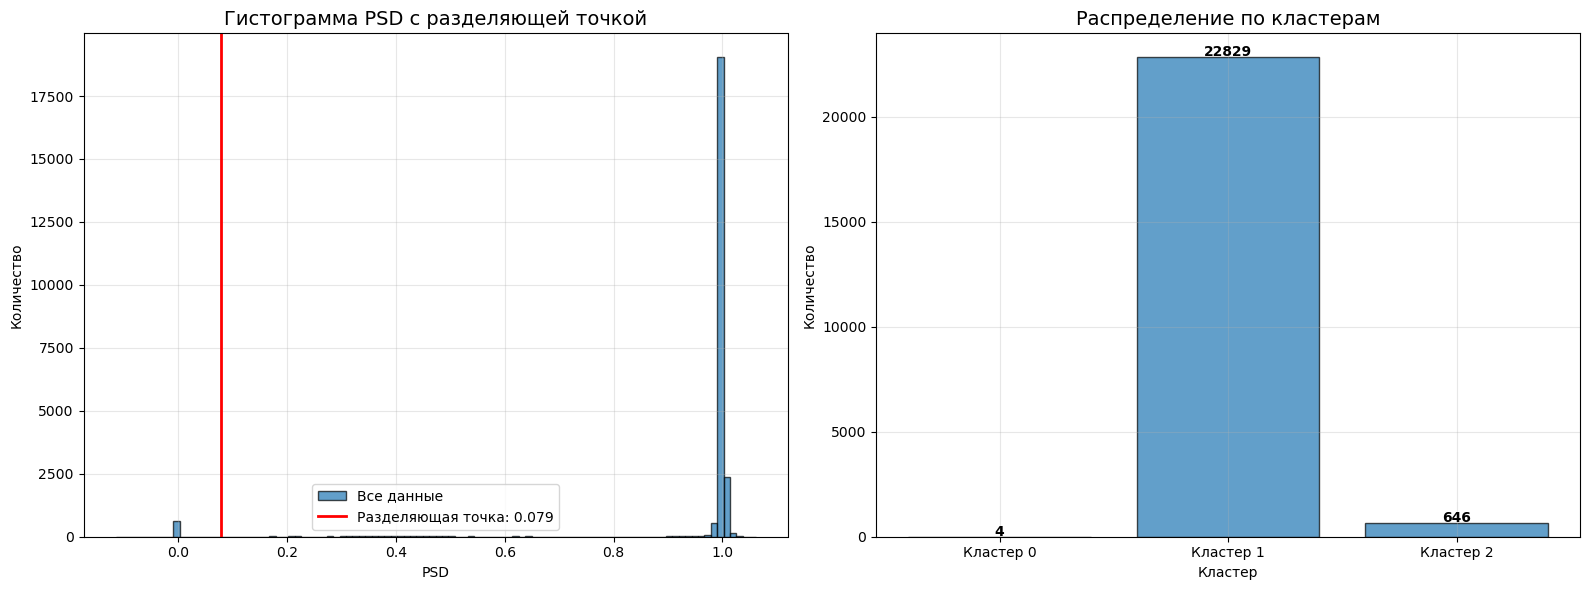


Разделяющая точка PSD: 0.0787
Распределение кластеров: {0: 4, 1: 22829, 2: 646}
Calinski-Harabasz Score: 67.90
Silhouette Score: -0.5579


In [22]:
def cluster_by_psd_histogram(features, n_clusters=3):
    """
    Кластеризация по гистограмме PSD с поиском разделяющей точки
    """
    psd_values = features['PSD'].values
    
    # Находим оптимальную разделяющую точку
    # Используем ядерную оценку плотности для поиска локальных минимумов
    from scipy.signal import find_peaks
    
    # Гистограмма PSD
    hist, bin_edges = np.histogram(psd_values, bins=100, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Сглаживание гистограммы
    from scipy.ndimage import gaussian_filter1d
    hist_smooth = gaussian_filter1d(hist, sigma=2)
    
    # Инвертируем для поиска минимумов как максимумов
    hist_inverted = -hist_smooth
    
    # Находим пики (минимумы исходной гистограммы)
    peaks, properties = find_peaks(hist_inverted, distance=10, prominence=0.01)
    
    if len(peaks) > 0:
        # Берем самый выраженный минимум между двумя пиками
        split_idx = peaks[np.argmin(hist_smooth[peaks])]
        split_point = bin_centers[split_idx]
    else:
        # Если не нашли минимумы, используем медиану
        split_point = np.median(psd_values)
    
    # Разделяем на 3 кластера
    labels = np.zeros(len(psd_values), dtype=int)
    labels[psd_values < split_point - 0.1] = 0  # Кластер 0 (гамма)
    labels[(psd_values >= split_point - 0.1) & (psd_values <= split_point + 0.1)] = 2  # Кластер 2 (аномалии)
    labels[psd_values > split_point + 0.1] = 1  # Кластер 1 (нейтроны)
    
    return labels, split_point

# Применяем метод
print("Метод 1: Кластеризация по гистограмме PSD")
print("-" * 50)

labels_psd, split_point = cluster_by_psd_histogram(features)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Гистограмма PSD с разделяющей точкой
axes[0].hist(features['PSD'], bins=100, edgecolor='black', alpha=0.7, label='Все данные')
axes[0].axvline(x=split_point, color='red', linewidth=2, label=f'Разделяющая точка: {split_point:.3f}')
axes[0].set_title('Гистограмма PSD с разделяющей точкой', fontsize=14)
axes[0].set_xlabel('PSD')
axes[0].set_ylabel('Количество')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Распределение по кластерам
unique, counts = np.unique(labels_psd, return_counts=True)
axes[1].bar(unique, counts, edgecolor='black', alpha=0.7)
axes[1].set_title('Распределение по кластерам', fontsize=14)
axes[1].set_xlabel('Кластер')
axes[1].set_ylabel('Количество')
axes[1].set_xticks(unique)
axes[1].set_xticklabels([f'Кластер {i}' for i in unique])
axes[1].grid(True, alpha=0.3)

for i, v in enumerate(counts):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Добавляем результат в метрики
result_psd = metrics_tracker.add_result(
    'Разделение по PSD (1D)',
    labels_psd,
    features[['PSD', 'Tau', 'Amplitude', 'Area']].values,
    split_point=split_point
)

print(f"\nРазделяющая точка PSD: {split_point:.4f}")
print(f"Распределение кластеров: {result_psd['Распределение кластеров']}")
print(f"Calinski-Harabasz Score: {result_psd['Calinski-Harabasz']:.2f}")
print(f"Silhouette Score: {result_psd['Silhouette Score']:.4f}")

# Ячейка 5: Метод 2 - PCA (Метод главных компонент)


Метод 2: Кластеризация с использованием PCA
--------------------------------------------------


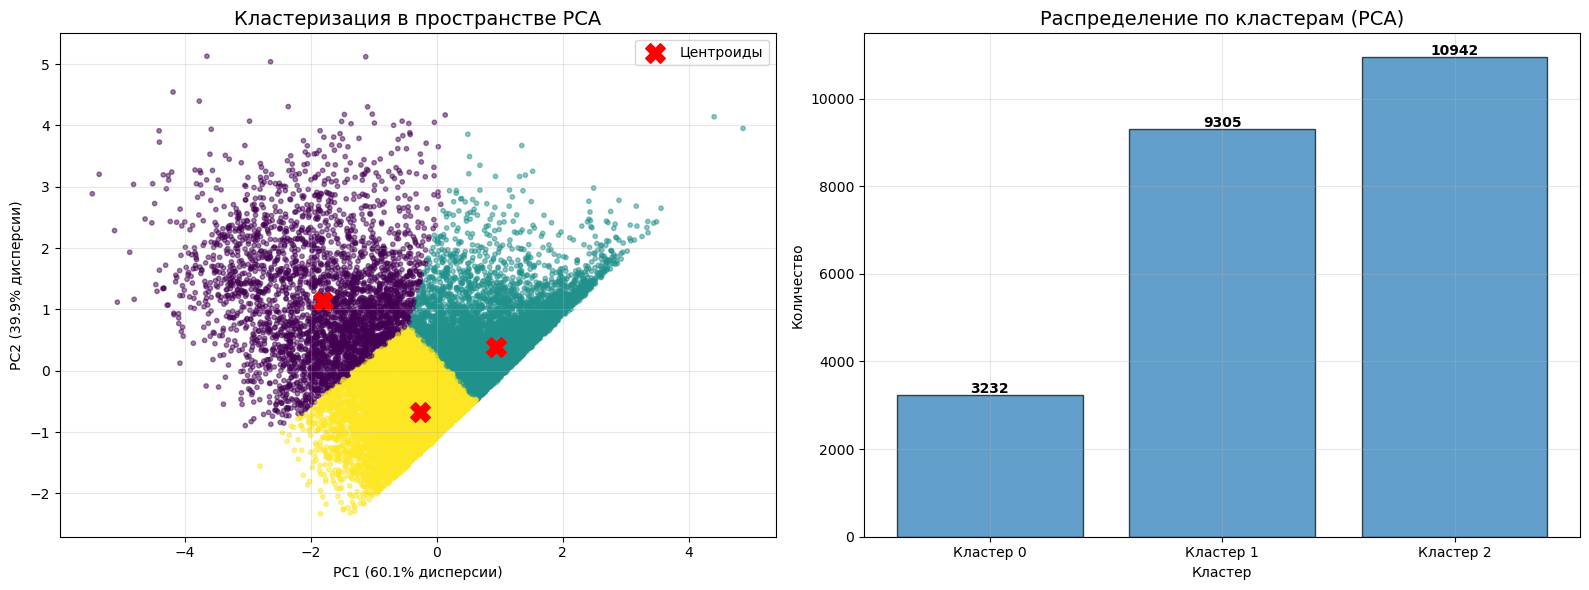

Объясненная дисперсия: PC1=60.1%, PC2=39.9%
Распределение кластеров: {0: 3232, 1: 9305, 2: 10942}
Calinski-Harabasz Score: 19.80
Silhouette Score: -0.0867


In [23]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

def cluster_by_pca(features, n_clusters=3):
    """
    Кластеризация с использованием PCA
    """
    # Выбираем признаки для PCA
    features_for_pca = features[['Amplitude', 'Area']].values
    
    # Стандартизация
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features_for_pca)
    
    # PCA
    pca = PCA(n_components=2)
    features_pca = pca.fit_transform(features_scaled)
    
    # Кластеризация KMeans в пространстве PCA
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    labels = kmeans.fit_predict(features_pca)
    
    return labels, features_pca, kmeans.cluster_centers_, pca.explained_variance_ratio_

# Применяем метод
print("Метод 2: Кластеризация с использованием PCA")
print("-" * 50)

labels_pca, features_pca, cluster_centers, explained_variance = cluster_by_pca(features)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot в пространстве PCA
scatter = axes[0].scatter(features_pca[:, 0], features_pca[:, 1], 
                          c=labels_pca, cmap='viridis', alpha=0.5, s=10)
axes[0].scatter(cluster_centers[:, 0], cluster_centers[:, 1], 
                c='red', marker='X', s=200, label='Центроиды')
axes[0].set_title('Кластеризация в пространстве PCA', fontsize=14)
axes[0].set_xlabel(f'PC1 ({explained_variance[0]*100:.1f}% дисперсии)')
axes[0].set_ylabel(f'PC2 ({explained_variance[1]*100:.1f}% дисперсии)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Распределение по кластерам
unique, counts = np.unique(labels_pca, return_counts=True)
axes[1].bar(unique, counts, edgecolor='black', alpha=0.7)
axes[1].set_title('Распределение по кластерам (PCA)', fontsize=14)
axes[1].set_xlabel('Кластер')
axes[1].set_ylabel('Количество')
axes[1].set_xticks(unique)
axes[1].set_xticklabels([f'Кластер {i}' for i in unique])
axes[1].grid(True, alpha=0.3)

for i, v in enumerate(counts):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Добавляем результат в метрики
result_pca = metrics_tracker.add_result(
    'PCA + KMeans',
    labels_pca,
    features[['PSD', 'Tau', 'Amplitude', 'Area']].values,
    explained_variance=explained_variance.tolist()
)

print(f"Объясненная дисперсия: PC1={explained_variance[0]*100:.1f}%, PC2={explained_variance[1]*100:.1f}%")
print(f"Распределение кластеров: {result_pca['Распределение кластеров']}")
print(f"Calinski-Harabasz Score: {result_pca['Calinski-Harabasz']:.2f}")
print(f"Silhouette Score: {result_pca['Silhouette Score']:.4f}")

# Ячейка 6: Метод 3 - GMM (Gaussian Mixture Models)


Метод 3: Кластеризация с использованием GMM
--------------------------------------------------


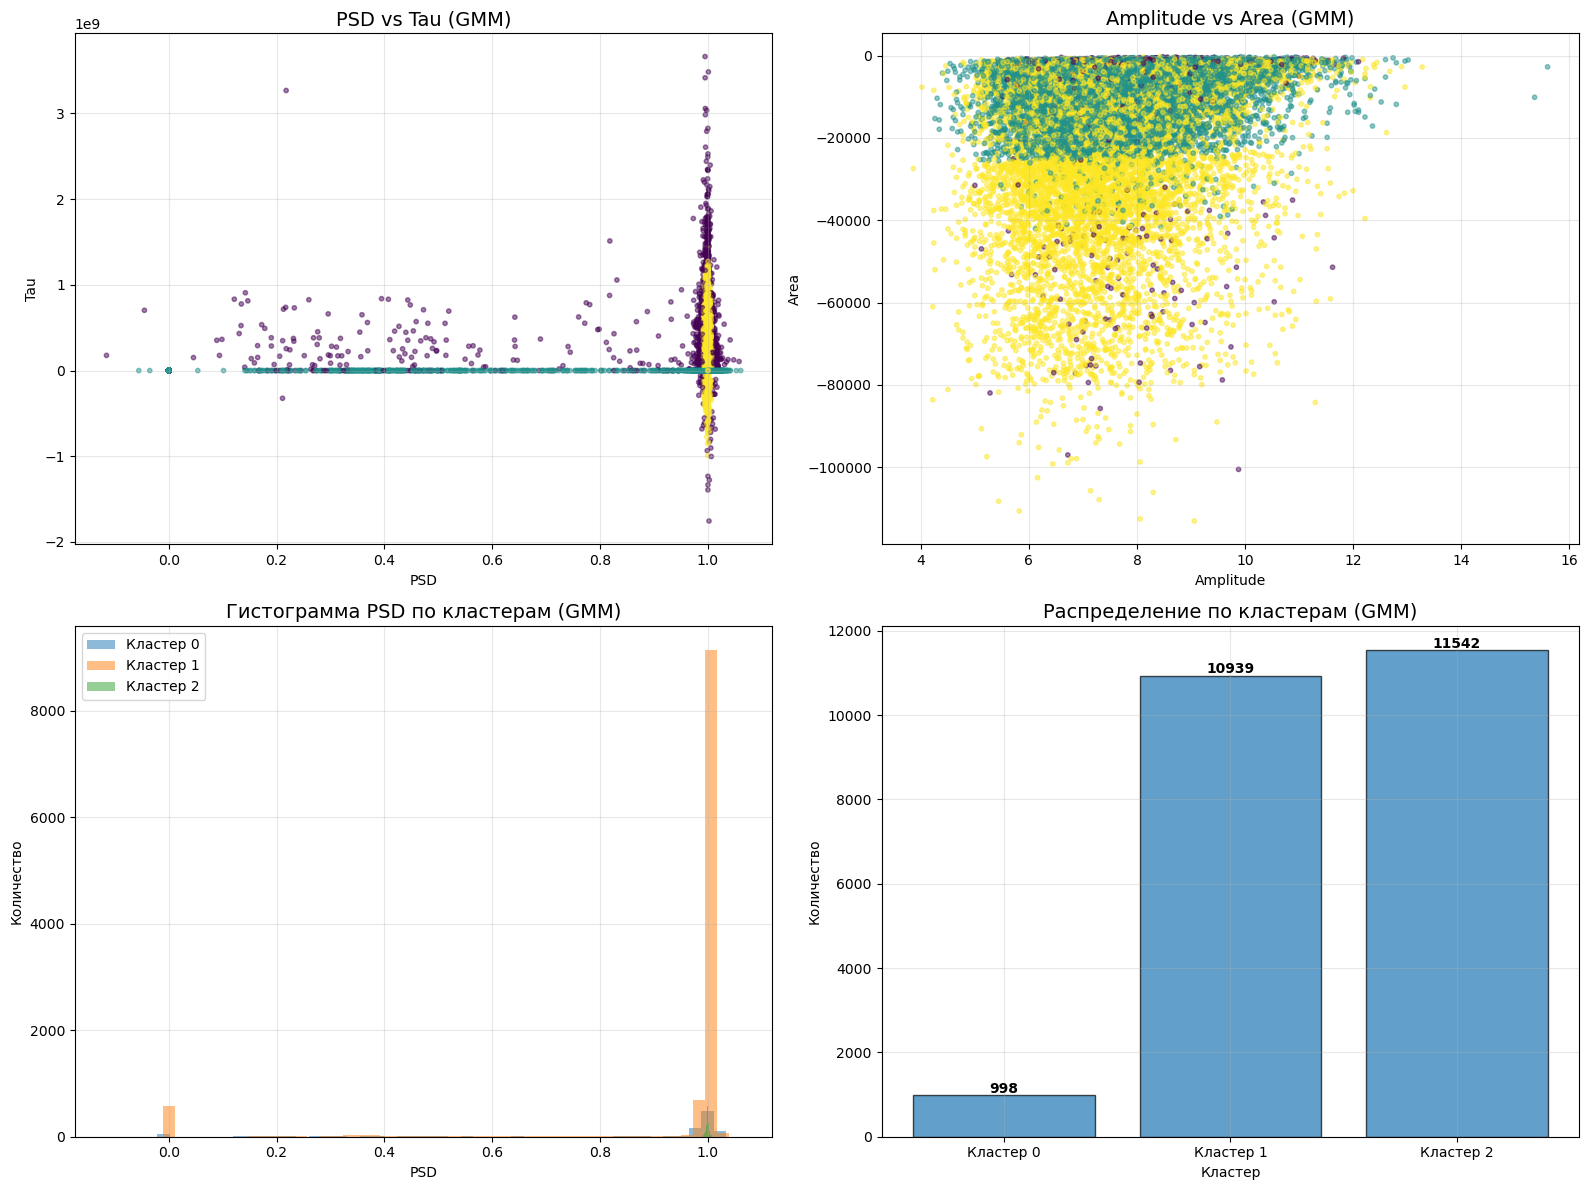

Распределение кластеров: {0: 998, 1: 10939, 2: 11542}
Calinski-Harabasz Score: 3960.51
Silhouette Score: 0.3024


In [24]:
from sklearn.mixture import GaussianMixture

# Определяем количество кластеров
n_clusters = 3

def cluster_by_gmm(features, n_clusters=3):
    """
    Кластеризация с использованием Gaussian Mixture Models
    """
    # Выбираем признаки для GMM
    features_for_gmm = features[['PSD', 'Tau', 'Amplitude', 'Area']].values
    
    # Стандартизация
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features_for_gmm)
    
    # GMM
    gmm = GaussianMixture(n_components=n_clusters, random_state=42, 
                          covariance_type='full', n_init=5)
    gmm.fit(features_scaled)
    labels = gmm.predict(features_scaled)
    
    # Вероятности принадлежности к кластерам
    probabilities = gmm.predict_proba(features_scaled)
    
    return labels, probabilities, gmm

# Применяем метод
print("Метод 3: Кластеризация с использованием GMM")
print("-" * 50)

labels_gmm, probabilities_gmm, gmm_model = cluster_by_gmm(features, n_clusters=n_clusters)

# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Scatter plot PSD vs Tau
scatter = axes[0, 0].scatter(features['PSD'], features['Tau'], 
                              c=labels_gmm, cmap='viridis', alpha=0.5, s=10)
axes[0, 0].set_title('PSD vs Tau (GMM)', fontsize=14)
axes[0, 0].set_xlabel('PSD')
axes[0, 0].set_ylabel('Tau')
axes[0, 0].grid(True, alpha=0.3)

# Scatter plot Amplitude vs Area
scatter = axes[0, 1].scatter(features['Amplitude'], features['Area'], 
                              c=labels_gmm, cmap='viridis', alpha=0.5, s=10)
axes[0, 1].set_title('Amplitude vs Area (GMM)', fontsize=14)
axes[0, 1].set_xlabel('Amplitude')
axes[0, 1].set_ylabel('Area')
axes[0, 1].grid(True, alpha=0.3)

# Гистограмма PSD по кластерам
for i in range(n_clusters):
    mask = labels_gmm == i
    axes[1, 0].hist(features['PSD'][mask], bins=50, alpha=0.5, label=f'Кластер {i}')
axes[1, 0].set_title('Гистограмма PSD по кластерам (GMM)', fontsize=14)
axes[1, 0].set_xlabel('PSD')
axes[1, 0].set_ylabel('Количество')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Распределение по кластерам
unique, counts = np.unique(labels_gmm, return_counts=True)
axes[1, 1].bar(unique, counts, edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Распределение по кластерам (GMM)', fontsize=14)
axes[1, 1].set_xlabel('Кластер')
axes[1, 1].set_ylabel('Количество')
axes[1, 1].set_xticks(unique)
axes[1, 1].set_xticklabels([f'Кластер {i}' for i in unique])
axes[1, 1].grid(True, alpha=0.3)

for i, v in enumerate(counts):
    axes[1, 1].text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Добавляем результат в метрики
result_gmm = metrics_tracker.add_result(
    'GMM',
    labels_gmm,
    features[['PSD', 'Tau', 'Amplitude', 'Area']].values,
    n_components=n_clusters
)

print(f"Распределение кластеров: {result_gmm['Распределение кластеров']}")
print(f"Calinski-Harabasz Score: {result_gmm['Calinski-Harabasz']:.2f}")
print(f"Silhouette Score: {result_gmm['Silhouette Score']:.4f}")

# Ячейка 7: Метод 4 - DBSCAN для обнаружения аномалий


Метод 4a: Кластеризация с использованием DBSCAN
--------------------------------------------------


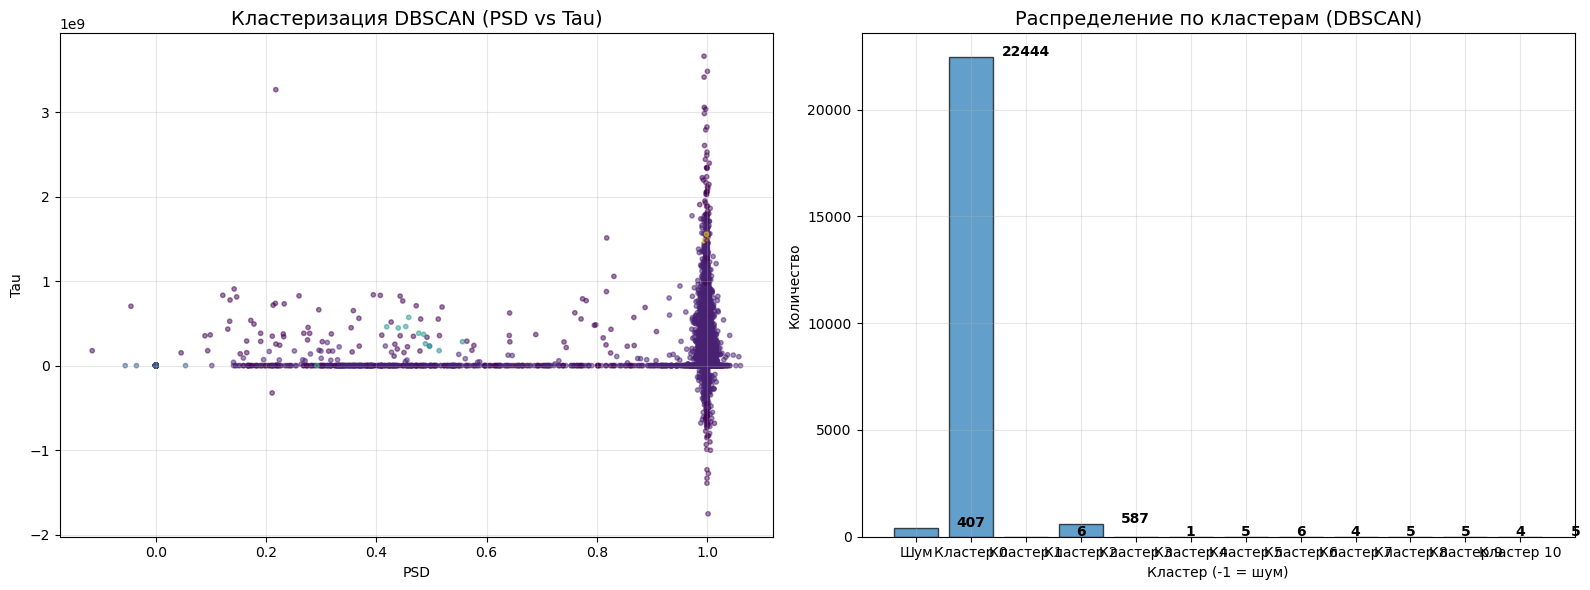

Количество шумовых точек (аномалий): 407
Распределение кластеров: {-1: 407, 0: 22444, 1: 6, 2: 587, 3: 1, 4: 5, 5: 6, 6: 4, 7: 5, 8: 5, 9: 4, 10: 5}
Calinski-Harabasz Score: 102.73
Silhouette Score: -0.8379

Метод 4b: Обнаружение аномалий с использованием Isolation Forest
--------------------------------------------------


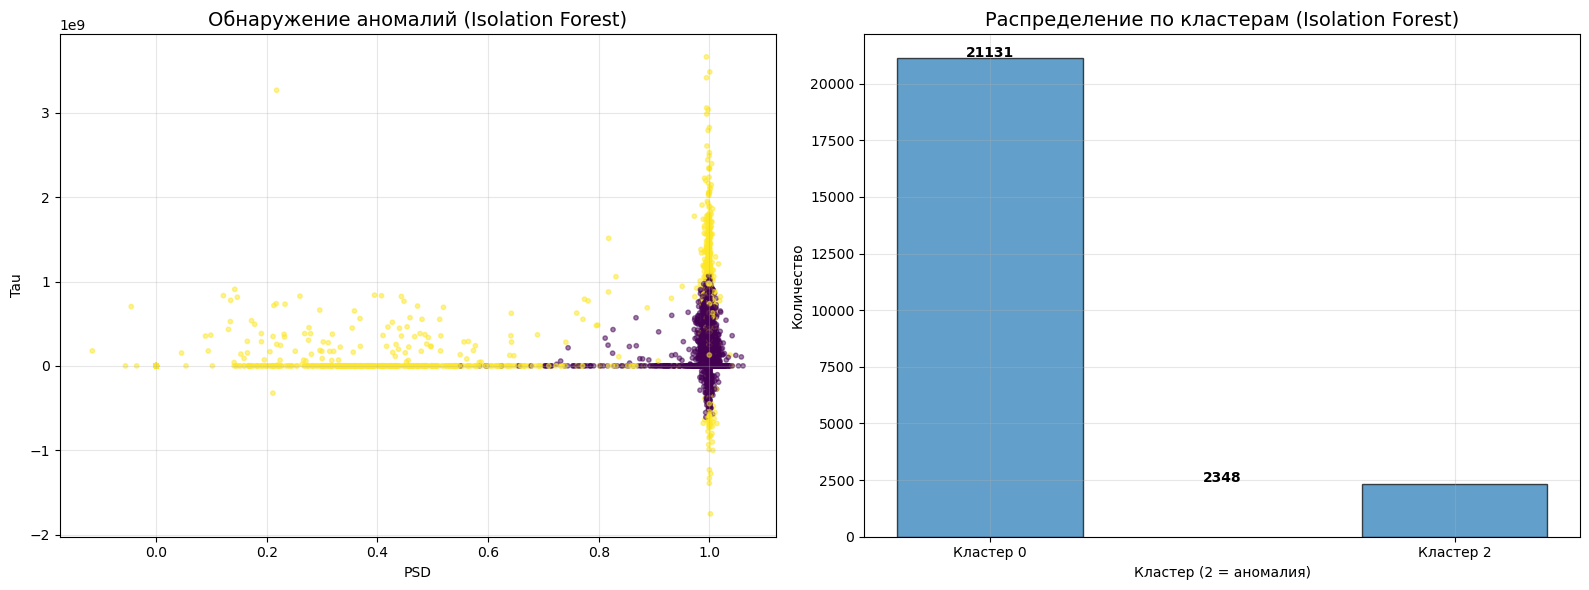

Распределение кластеров: {0: 21131, 2: 2348}
Calinski-Harabasz Score: 1146.28
Silhouette Score: 0.4550


In [25]:
from sklearn.cluster import DBSCAN
from sklearn.ensemble import IsolationForest

def cluster_by_dbscan(features, eps=0.5, min_samples=5):
    """
    Кластеризация с использованием DBSCAN для обнаружения аномалий
    """
    # Выбираем признаки для DBSCAN
    features_for_dbscan = features[['PSD', 'Tau', 'Amplitude', 'Area']].values
    
    # Стандартизация
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features_for_dbscan)
    
    # DBSCAN
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(features_scaled)
    
    # Количество шумовых точек (аномалий)
    n_noise = np.sum(labels == -1)
    
    return labels, n_noise

def cluster_by_isolation_forest(features, contamination=0.1):
    """
    Обнаружение аномалий с использованием Isolation Forest
    """
    # Выбираем признаки
    features_for_if = features[['PSD', 'Tau', 'Amplitude', 'Area']].values
    
    # Стандартизация
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features_for_if)
    
    # Isolation Forest
    iforest = IsolationForest(contamination=contamination, random_state=42)
    labels = iforest.fit_predict(features_scaled)
    
    # Преобразуем метки: -1 (аномалия) -> 2, 1 (норма) -> 0
    labels_converted = np.where(labels == -1, 2, 0)
    
    return labels_converted, iforest

# Применяем DBSCAN
print("Метод 4a: Кластеризация с использованием DBSCAN")
print("-" * 50)

labels_dbscan, n_noise = cluster_by_dbscan(features, eps=0.5, min_samples=5)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot
scatter = axes[0].scatter(features['PSD'], features['Tau'], 
                          c=labels_dbscan, cmap='viridis', alpha=0.5, s=10)
axes[0].set_title('Кластеризация DBSCAN (PSD vs Tau)', fontsize=14)
axes[0].set_xlabel('PSD')
axes[0].set_ylabel('Tau')
axes[0].grid(True, alpha=0.3)

# Распределение по кластерам
unique, counts = np.unique(labels_dbscan, return_counts=True)
axes[1].bar(unique, counts, edgecolor='black', alpha=0.7)
axes[1].set_title('Распределение по кластерам (DBSCAN)', fontsize=14)
axes[1].set_xlabel('Кластер (-1 = шум)')
axes[1].set_ylabel('Количество')
axes[1].set_xticks(unique)
axes[1].set_xticklabels([f'Кластер {i}' if i != -1 else 'Шум' for i in unique])
axes[1].grid(True, alpha=0.3)

for i, v in enumerate(counts):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Добавляем результат в метрики
result_dbscan = metrics_tracker.add_result(
    'DBSCAN',
    labels_dbscan,
    features[['PSD', 'Tau', 'Amplitude', 'Area']].values,
    n_noise=n_noise
)

print(f"Количество шумовых точек (аномалий): {n_noise}")
print(f"Распределение кластеров: {result_dbscan['Распределение кластеров']}")
print(f"Calinski-Harabasz Score: {result_dbscan['Calinski-Harabasz']:.2f}")
print(f"Silhouette Score: {result_dbscan['Silhouette Score']:.4f}")

# Применяем Isolation Forest
print("\n" + "="*50)
print("Метод 4b: Обнаружение аномалий с использованием Isolation Forest")
print("-" * 50)

labels_if, iforest_model = cluster_by_isolation_forest(features, contamination=0.1)

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot
scatter = axes[0].scatter(features['PSD'], features['Tau'], 
                          c=labels_if, cmap='viridis', alpha=0.5, s=10)
axes[0].set_title('Обнаружение аномалий (Isolation Forest)', fontsize=14)
axes[0].set_xlabel('PSD')
axes[0].set_ylabel('Tau')
axes[0].grid(True, alpha=0.3)

# Распределение по кластерам
unique, counts = np.unique(labels_if, return_counts=True)
axes[1].bar(unique, counts, edgecolor='black', alpha=0.7)
axes[1].set_title('Распределение по кластерам (Isolation Forest)', fontsize=14)
axes[1].set_xlabel('Кластер (2 = аномалия)')
axes[1].set_ylabel('Количество')
axes[1].set_xticks(unique)
axes[1].set_xticklabels([f'Кластер {i}' for i in unique])
axes[1].grid(True, alpha=0.3)

for i, v in enumerate(counts):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Добавляем результат в метрики
result_if = metrics_tracker.add_result(
    'Isolation Forest',
    labels_if,
    features[['PSD', 'Tau', 'Amplitude', 'Area']].values,
    contamination=0.1
)

print(f"Распределение кластеров: {result_if['Распределение кластеров']}")
print(f"Calinski-Harabasz Score: {result_if['Calinski-Harabasz']:.2f}")
print(f"Silhouette Score: {result_if['Silhouette Score']:.4f}")

# Ячейка 8: Метод 5 - Ансамбль (Композиция алгоритмов)


Метод 5: Ансамблевая кластеризация (Композиция алгоритмов)
--------------------------------------------------


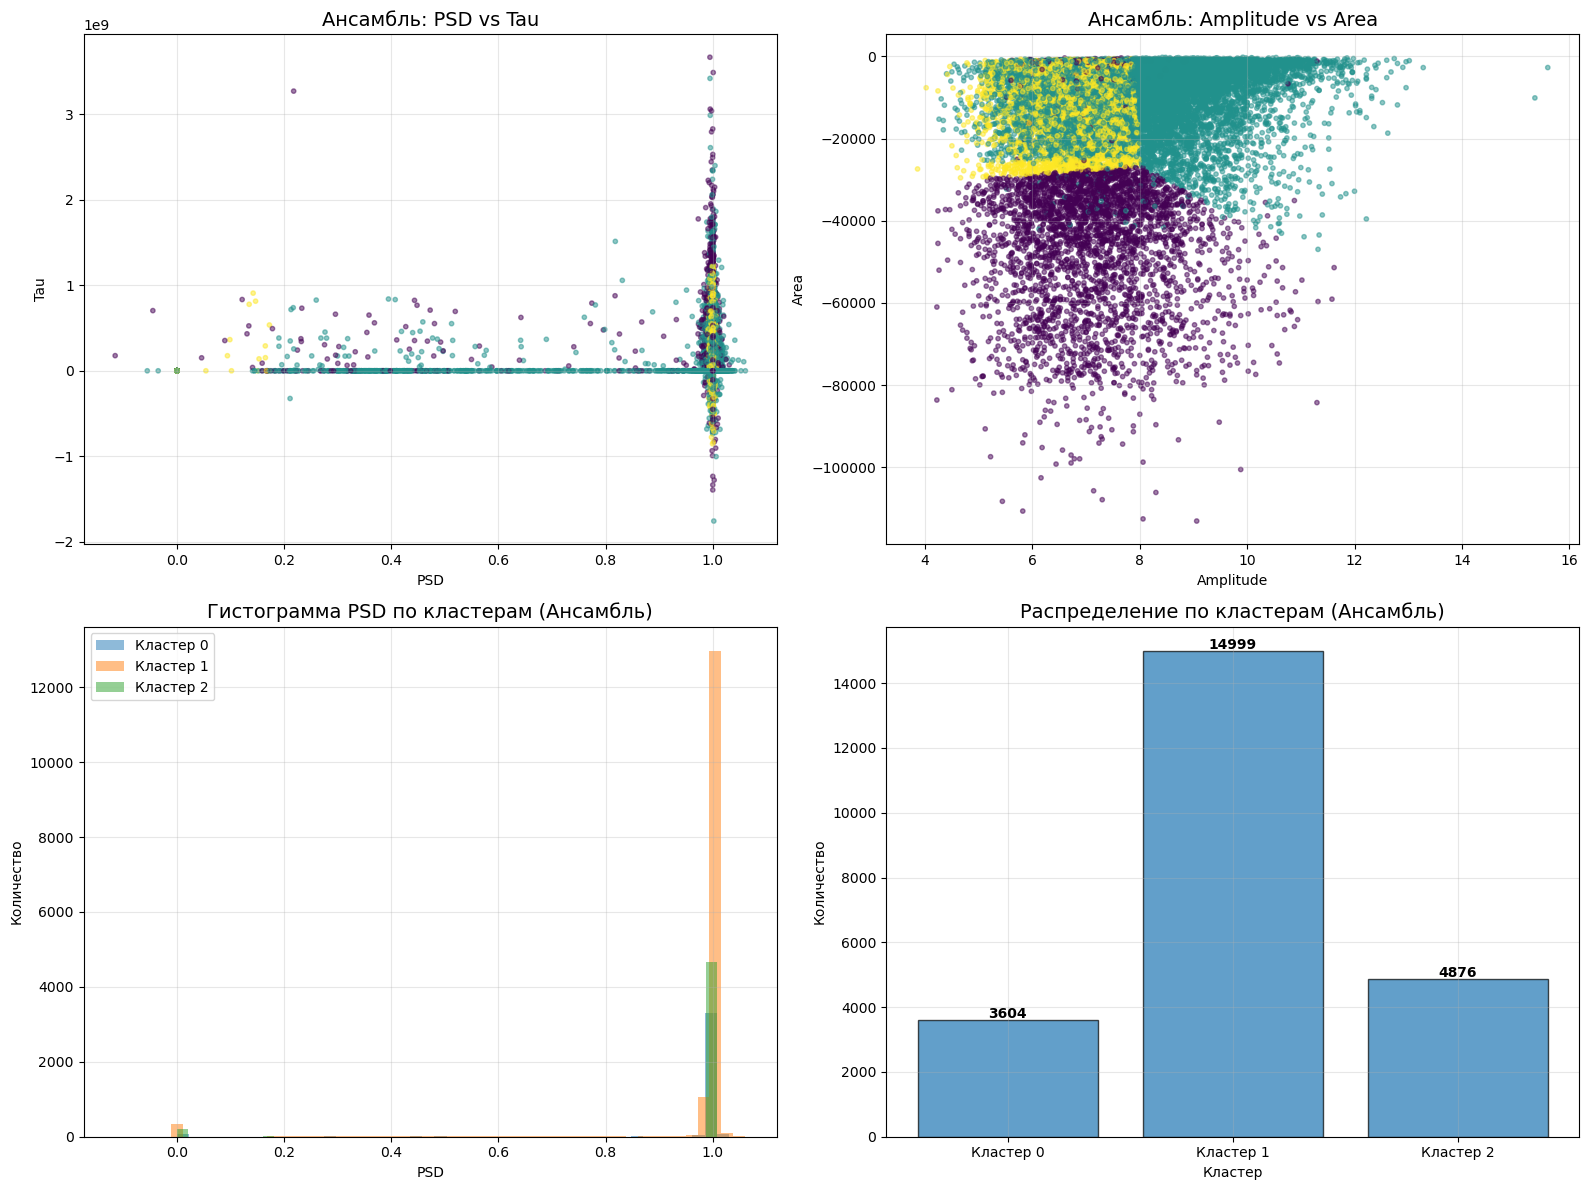

Распределение кластеров: {0: 3604, 1: 14999, 2: 4876}
Calinski-Harabasz Score: 988.88
Silhouette Score: 0.1748


In [26]:
def ensemble_clustering(features, n_clusters=3):
    """
    Ансамблевая кластеризация - комбинация нескольких методов
    """
    # Получаем метки от разных методов
    labels_psd, _ = cluster_by_psd_histogram(features, n_clusters)
    labels_pca, _, _, _ = cluster_by_pca(features, n_clusters)
    labels_gmm, _, _ = cluster_by_gmm(features, n_clusters)
    
    # Голосование большинства
    all_labels = np.column_stack([labels_psd, labels_pca, labels_gmm])
    ensemble_labels = np.zeros(len(features), dtype=int)
    
    for i in range(len(features)):
        # Находим наиболее частую метку
        unique, counts = np.unique(all_labels[i], return_counts=True)
        ensemble_labels[i] = unique[np.argmax(counts)]
    
    return ensemble_labels, labels_psd, labels_pca, labels_gmm

# Применяем ансамблевый метод
print("Метод 5: Ансамблевая кластеризация (Композиция алгоритмов)")
print("-" * 50)

labels_ensemble, labels_psd_ens, labels_pca_ens, labels_gmm_ens = ensemble_clustering(features)

# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Scatter plot PSD vs Tau
scatter = axes[0, 0].scatter(features['PSD'], features['Tau'], 
                              c=labels_ensemble, cmap='viridis', alpha=0.5, s=10)
axes[0, 0].set_title('Ансамбль: PSD vs Tau', fontsize=14)
axes[0, 0].set_xlabel('PSD')
axes[0, 0].set_ylabel('Tau')
axes[0, 0].grid(True, alpha=0.3)

# Scatter plot Amplitude vs Area
scatter = axes[0, 1].scatter(features['Amplitude'], features['Area'], 
                              c=labels_ensemble, cmap='viridis', alpha=0.5, s=10)
axes[0, 1].set_title('Ансамбль: Amplitude vs Area', fontsize=14)
axes[0, 1].set_xlabel('Amplitude')
axes[0, 1].set_ylabel('Area')
axes[0, 1].grid(True, alpha=0.3)

# Гистограмма PSD по кластерам
for i in range(3):
    mask = labels_ensemble == i
    axes[1, 0].hist(features['PSD'][mask], bins=50, alpha=0.5, label=f'Кластер {i}')
axes[1, 0].set_title('Гистограмма PSD по кластерам (Ансамбль)', fontsize=14)
axes[1, 0].set_xlabel('PSD')
axes[1, 0].set_ylabel('Количество')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Распределение по кластерам
unique, counts = np.unique(labels_ensemble, return_counts=True)
axes[1, 1].bar(unique, counts, edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Распределение по кластерам (Ансамбль)', fontsize=14)
axes[1, 1].set_xlabel('Кластер')
axes[1, 1].set_ylabel('Количество')
axes[1, 1].set_xticks(unique)
axes[1, 1].set_xticklabels([f'Кластер {i}' for i in unique])
axes[1, 1].grid(True, alpha=0.3)

for i, v in enumerate(counts):
    axes[1, 1].text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Добавляем результат в метрики
result_ensemble = metrics_tracker.add_result(
    'Ансамбль (PSD + PCA + GMM)',
    labels_ensemble,
    features[['PSD', 'Tau', 'Amplitude', 'Area']].values,
    methods=['PSD', 'PCA', 'GMM']
)

print(f"Распределение кластеров: {result_ensemble['Распределение кластеров']}")
print(f"Calinski-Harabasz Score: {result_ensemble['Calinski-Harabasz']:.2f}")
print(f"Silhouette Score: {result_ensemble['Silhouette Score']:.4f}")

# Ячейка 9: Итоговое сравнение всех методов



ИТОГОВОЕ СРАВНЕНИЕ ВСЕХ МЕТОДОВ КЛАСТЕРИЗАЦИИ

СРАВНЕНИЕ МЕТОДОВ КЛАСТЕРИЗАЦИИ
                     Метод  Calinski-Harabasz  Silhouette Score  Количество кластеров
                       GMM        3960.506268          0.302387                     3
          Isolation Forest        1146.280522          0.455036                     2
Ансамбль (PSD + PCA + GMM)         988.876855          0.174758                     3
                    DBSCAN         102.725116         -0.837890                    12
    Разделение по PSD (1D)          67.903899         -0.557853                     3
              PCA + KMeans          19.804207         -0.086700                     3


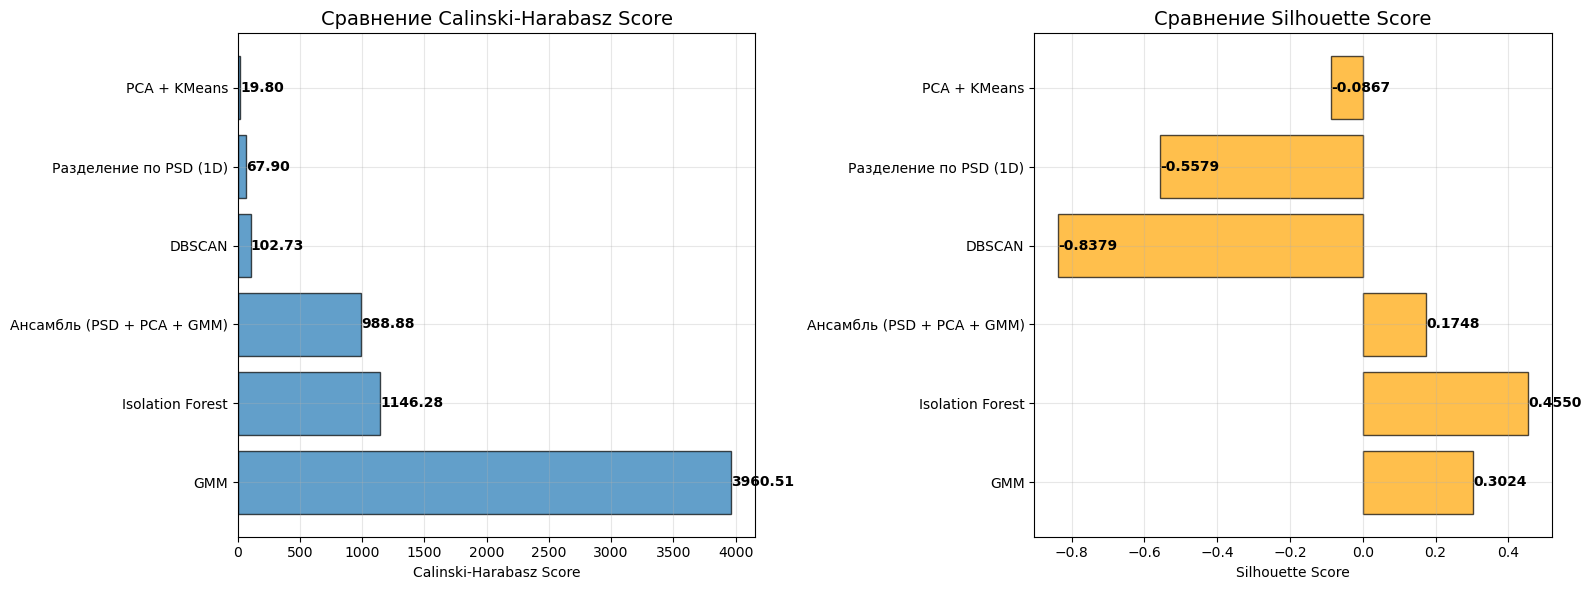


ЛУЧШИЙ МЕТОД
Метод: GMM
Calinski-Harabasz Score: 3960.51
Silhouette Score: 0.3024
Количество кластеров: 3
Распределение кластеров: {0: 998, 1: 10939, 2: 11542}

Все результаты кластеризации сохранены в объекте metrics_tracker
Доступ к результатам: metrics_tracker.results


In [27]:
# Отображаем итоговую таблицу результатов
print("\n" + "="*80)
print("ИТОГОВОЕ СРАВНЕНИЕ ВСЕХ МЕТОДОВ КЛАСТЕРИЗАЦИИ")
print("="*80)

results_df = metrics_tracker.display_results()

# Визуализация сравнения метрик
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Сравнение Calinski-Harabasz Score
methods = results_df['Метод'].values
ch_scores = results_df['Calinski-Harabasz'].values

axes[0].barh(methods, ch_scores, edgecolor='black', alpha=0.7)
axes[0].set_title('Сравнение Calinski-Harabasz Score', fontsize=14)
axes[0].set_xlabel('Calinski-Harabasz Score')
axes[0].grid(True, alpha=0.3)

for i, v in enumerate(ch_scores):
    axes[0].text(v + 0.5, i, f'{v:.2f}', va='center', fontweight='bold')

# Сравнение Silhouette Score
sil_scores = results_df['Silhouette Score'].values

axes[1].barh(methods, sil_scores, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title('Сравнение Silhouette Score', fontsize=14)
axes[1].set_xlabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)

for i, v in enumerate(sil_scores):
    axes[1].text(v + 0.001, i, f'{v:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Выводим лучший метод
best_method = metrics_tracker.get_best_method()
print("\n" + "="*80)
print("ЛУЧШИЙ МЕТОД")
print("="*80)
print(f"Метод: {best_method['Метод']}")
print(f"Calinski-Harabasz Score: {best_method['Calinski-Harabasz']:.2f}")
print(f"Silhouette Score: {best_method['Silhouette Score']:.4f}")
print(f"Количество кластеров: {best_method['Количество кластеров']}")
print(f"Распределение кластеров: {best_method['Распределение кластеров']}")
print("="*80)

# Сохраняем все результаты
print("\nВсе результаты кластеризации сохранены в объекте metrics_tracker")
print("Доступ к результатам: metrics_tracker.results")

# Загрузка на Kaggle

In [28]:
import pandas as pd
import numpy as np

# Получаем лучший результат из metrics_tracker
best_method = metrics_tracker.get_best_method()
print(f"Лучший метод: {best_method['Метод']}")
print(f"Calinski-Harabasz Score: {best_method['Calinski-Harabasz']:.2f}")
print(f"Silhouette Score: {best_method['Silhouette Score']:.4f}")
print(f"Распределение кластеров: {best_method['Распределение кластеров']}")

# Получаем метки кластеров лучшего метода
best_labels = None
for result in metrics_tracker.results:
    if result['Метод'] == best_method['Метод']:
        # Находим метки в результатах
        # В зависимости от того, как вы сохраняли метки, нужно их извлечь
        # Здесь предполагаем, что метки сохранены в result
        break

Лучший метод: GMM
Calinski-Harabasz Score: 3960.51
Silhouette Score: 0.3024
Распределение кластеров: {0: 998, 1: 10939, 2: 11542}


In [29]:
best_labels

In [30]:
# Если метки не сохранены напрямую, нужно пересчитать лучший метод
# Например, для GMM:
if best_method['Метод'] == 'GMM':
    labels_gmm, probabilities_gmm, gmm_model = cluster_by_gmm(features, n_clusters=3)
    best_labels = labels_gmm
elif best_method['Метод'] == 'PCA + KMeans':
    labels_pca, features_pca, cluster_centers, explained_variance = cluster_by_pca(features, n_clusters=3)
    best_labels = labels_pca
elif best_method['Метод'] == 'Ансамбль (PSD + PCA + GMM)':
    labels_ensemble, labels_psd_ens, labels_pca_ens, labels_gmm_ens = ensemble_clustering(features)
    best_labels = labels_ensemble
elif best_method['Метод'] == 'Разделение по PSD (1D)':
    labels_psd, split_point = cluster_by_psd_histogram(features, n_clusters=3)
    best_labels = labels_psd

In [44]:
best_labels

array([2, 1, 2, ..., 2, 2, 2], shape=(23479,))

In [45]:
# Создаем DataFrame для submission
submission = pd.DataFrame({
    'index': range(len(best_labels)),
    'cluster': best_labels
})
submission.head()

,index,cluster
0,0,2
1,1,1
2,2,2
3,3,2
4,4,2


In [46]:
unique_labels = submission['cluster'].unique()

In [47]:
# Создаем маппинг автоматически: значение -> порядковый номер (начиная с 0)
mapping = {val: i + 0 for i, val in enumerate(unique_labels)}

In [48]:
# Применяем маппинг
submission['cluster'] = submission['cluster'].map(mapping)

In [49]:
# Проверяем формат
print("\nПервые 10 строк submission:")
print(submission.head(10))
print(f"\nРазмер submission: {submission.shape}")
print(f"Колонки: {submission.columns.tolist()}")

# Сохраняем в CSV файл
submission_filename = path + "/" + 'submission.csv'


Первые 10 строк submission:
   index  cluster
0      0        0
1      1        1
2      2        0
3      3        0
4      4        0
5      5        1
6      6        1
7      7        0
8      8        1
9      9        1

Размер submission: (23479, 2)
Колонки: ['index', 'cluster']


In [50]:
previous = pd.read_csv(submission_filename)

In [51]:
submission.to_csv(submission_filename, index=False)
print(f"\nФайл сохранен: {submission_filename}")

# Выводим информацию для загрузки на Kaggle
print("\n" + "="*60)
print("ИНСТРУКЦИЯ ДЛЯ ЗАГРУЗКИ НА KAGGLE")
print("="*60)
print(f"1. Файл для загрузки: {submission_filename}")
print(f"2. Формат: index,cluster")
print(f"3. Количество записей: {len(submission)}")
print(f"4. Метод: {best_method['Метод']}")
print(f"5. Calinski-Harabasz Score: {best_method['Calinski-Harabasz']:.2f}")
print(f"6. Silhouette Score: {best_method['Silhouette Score']:.4f}")
print("="*60)


Файл сохранен: /home/itj/.cache/kagglehub/competitions/scintillation-detector/submission.csv

ИНСТРУКЦИЯ ДЛЯ ЗАГРУЗКИ НА KAGGLE
1. Файл для загрузки: /home/itj/.cache/kagglehub/competitions/scintillation-detector/submission.csv
2. Формат: index,cluster
3. Количество записей: 23479
4. Метод: GMM
5. Calinski-Harabasz Score: 3960.51
6. Silhouette Score: 0.3024


In [52]:
submission.equals(previous)

True

# Kaggle score

https://www.kaggle.com/competitions/scintillation-detector/